# Functions

In [6]:
import pickle as pkl 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy.optimize import fsolve
import matplotlib as mpl
import seaborn as sns 
import pandas as pd

mpl.use('Qt5Agg')

/tmp/ipykernel_383121/710946296.py:10: MatplotlibDeprecationWarning: Auto-close()ing of figures upon backend switching is deprecated since 3.8 and will be removed two minor releases later.  To suppress this warning, explicitly call plt.close('all') first.
  mpl.use('Qt5Agg')


In [7]:
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 17

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)            # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE) 

In [8]:
def Pres(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N):
    #Note mxenv (x=a,A;env=pre,post) refers to the effective rates \tilde{m}_{x,env} in the manuscript for this
    
    mueffpre = (1-mApre)*mu + mApre*nu 
    mueffpost = (1-mApost)*mu + mApost*nu 
    paeff = mueffpre/((1-(mapre*hbpre+mApre*hBpre))*spre)
    
    if mApost*hBpost*spost-r < 0:
        Nsgv = paeff*N 
        Ndenovo = mueffpost/(r-mApost*hBpost*spost)*(1-paeff)*N
        Pgen = 1 - np.exp(-2*((1-mapost*hbpost)*spost-r)*(Nsgv + Ndenovo)) if (1-mapost*hbpost)*spost-r > 0 else 0
    else:
        Pgen = 1 - np.exp(-2*((1-mapost*hbpost)*spost-r)) if (1-mapost*hbpost)*spost-r > 0 and mueffpost > 0 else 0
    
    Nwild = (1-paeff)*N
    Pepi = 1 - np.exp(-2*(mApost*hBpost*spost-r)*Nwild) if mApost*hBpost*spost-r > 0 else 0 
    
    if Pgen < 0 or Pepi < 0 : 
        print("Error", paeff)
    if Pgen > 1 or Pepi > 1: 
        print("Error", paeff)
    return 1 - (1-Pgen)*(1-Pepi)

def prechange_det(spre,hbpre,hBpre,mapre,mApre,tapre,tApre,mu,nu,timeseries=False, NoG=10**5):
    pA = 1
    pB = 0 
    pa = 0
    pb = 0 
    
    wA = 1
    wa = 1-spre
    wB = 1-hBpre*spre
    wb = 1-(1-hbpre)*spre
    
    gen = 0
    
    if timeseries: 
        pAlist = []
        pBlist = []
        palist = []
        pblist = [] 
        
    
    while True: 
        #print(pA,pa,pB,pb)
        pAs = wA*pA
        pas = wa*pa
        pBs = wB*pB
        pbs = wb*pb
        
        pAmut = (1-mApre)*(1-mu)*pAs + tApre*(1-nu)*pBs + mu*pas 
        pamut = (1-mapre)*(1-mu)*pas + tapre*(1-nu)*pbs + mu*pAs 
        pBmut = (1-tApre)*(1-nu)*pBs + mApre*(1-mu)*pAs + nu*pbs
        pbmut = (1-tapre)*(1-nu)*pbs + mapre*(1-mu)*pas + nu*pBs
        
        wavg = pAmut + pamut + pBmut + pbmut
        
        pAnext = pAmut/wavg
        pBnext = pBmut/wavg
        panext = pamut/wavg
        pbnext = 1-pAnext-pBnext-panext
        
        gen += 1 
        
        if gen > NoG: 
            break
        pA = pAnext 
        pB = pBnext 
        pa = panext 
        pb = pbnext 
        
        if timeseries: 
            pAlist += [pA]
            pBlist += [pB]
            palist += [pa]
            pblist += [pb]
    if timeseries: 
        return [pAlist, palist, pBlist, pblist, pAnext, panext, pBnext, pbnext]
    return [pAnext,panext,pBnext,pbnext]


def Post_change_stochastic_dynamics(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,tapre,tApre,tApost,tapost,mu,nu,N): 
    #print(m,t,s)
    mApre_eff = mApre/(mApre+tApre)
    mapre_eff = mapre/(mapre+tapre)
    mApost_eff = mApost/(mApost+tApost)
    mapost_eff = mapost/(mapost+tapost)
    
    mueffpre = (1-mApre_eff)*mu + mApre_eff*nu 
    mueffpost = (1-mApost_eff)*mu + mApost_eff*nu 
    paeff = mueffpre/((1-(mapre_eff*hbpre+mApre_eff*hBpre))*spre)
    
    NA_list = [round((1-mApre)*(1-paeff)*N)]
    NB_list = [round(mApre*(1-paeff)*N)]
    Na_list = [round((1-mapre)*paeff*N)]
    Nb_list = [N-NA_list[-1]-NB_list[-1]-Na_list[-1]]
    
    
    recovered = 0
    extinct = 0 
    number_of_recoveries = 0 
    
    while True: 
        NA = NA_list[-1]
        NB = NB_list[-1]
        Na = Na_list[-1]
        Nb = Nb_list[-1]
        
        WA = 1-r
        WB = 1-r+hBpost*spost
        Wb = 1-r+(1-hbpost)*spost
        Wa = 1-r+spost
        
        lamA = (1-mu)*(1-mApost)*WA*NA + (1-nu)*tApost*WB*NB + mu*Wa*Na
        lamB = (1-nu)*(1-tApost)*WB*NB + (1-mu)*mApost*WA*NA + nu*Wb*Nb
        lama = (1-mu)*(1-mapost)*Wa*Na + (1-nu)*tapost*Wb*Nb + mu*WA*NA
        lamb = (1-nu)*(1-tapost)*Wb*Nb + (1-mu)*mapost*Wa*Na + nu*WB*NB
                
        NA_offsprings = np.random.poisson(lam=lamA)
        NB_offsprings = np.random.poisson(lam=lamB)
        Na_offsprings = np.random.poisson(lam=lama)
        Nb_offsprings = np.random.poisson(lam=lamb)
        N_Total  = NA_offsprings + NB_offsprings + Na_offsprings + Nb_offsprings         
            
        
        if N_Total == 0: 
            extinct = 1
            NA_list += [NA_offsprings]
            NB_list += [NB_offsprings]
            Na_list += [Na_offsprings]
            Nb_list += [Nb_offsprings]
            break
        elif N_Total <= N :
            NA_list += [NA_offsprings]
            NB_list += [NB_offsprings]
            Na_list += [Na_offsprings]
            Nb_list += [Nb_offsprings]
        else: 
            recovered = 1 
            number_of_recoveries += 1
            NA_survived = round(NA_offsprings/float(N_Total)*(N))
            NB_survived = round(NB_offsprings/float(N_Total)*(N))
            Na_survived = round(Na_offsprings/float(N_Total)*(N))
            
            NA_list += [NA_survived]
            NB_list += [NB_survived]
            Na_list += [Na_survived]
            Nb_list += [N - NA_survived - NB_survived - Na_survived]                  
            if number_of_recoveries == 100:
                break 
                
            #NA_list += [NA_offsprings]
            #NB_list += [NB_offsprings]                  
            
            
    return [NA_list,NB_list,Na_list,Nb_list,recovered,extinct,number_of_recoveries]




## Quasi Epigenetic Equilibrium 

seed 40


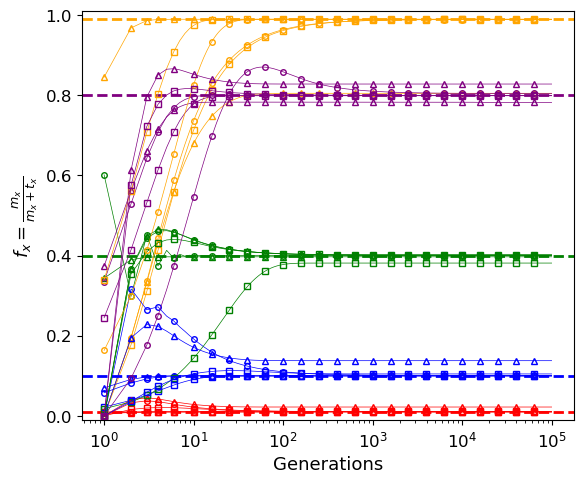

In [9]:
x_range = [0.01,0.1,0.4,0.8,0.99]    
svalues = [0.001,0.01, 0.1]

colors = ['red','blue','green','purple','orange']
mkrs = ['o','s','^']

%matplotlib inline
fig = plt.figure(figsize=(6,5))

seed = round(np.random.random()*1000)
print("seed",seed)
np.random.seed(30) #989 #20 #30
for x_ind, x in enumerate(x_range): 
    x = round(x,3)
    plt.axhline(y=x, linestyle = '--', color=colors[x_ind], linewidth=2)
    for spre_ind, spre in enumerate(svalues): 
        for rep in range(1): 
            mA = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
            tA = (1-x)*mA/x if x != 0 else np.random.random()
            xa = x_range[x_ind-1]
            ma = np.random.random()*min(xa/(1-xa),1) if xa != 1 else np.random.random()
            ta = (1-xa)*ma/xa if xa != 0 else np.random.random()
            
            hbpre = np.random.random() 
            hBpre = np.random.random() 
            mu = 10**(-6)
            nu = 10**(-6)
            output = prechange_det(spre=spre,hbpre=hbpre,hBpre=hBpre,mapre=ma,mApre=mA,tapre=ta,tApre=tA,mu=mu,nu=nu,timeseries=True)
            mnorm_A = np.array(output[2])/(np.array(output[0]) + np.array(output[2])) 
            mnorm_a = np.array(output[3])/(np.array(output[1]) + np.array(output[3])) 
            mkevry = [round(10**exp)-1 for exp in np.arange(0,5,0.2)] 
            plt.plot( range(1,1+len(mnorm_A)), mnorm_A, ms=4, markevery= mkevry, marker=mkrs[spre_ind] , fillstyle = 'none', color = colors[x_ind], linewidth = 0.5) 
            plt.plot( range(1,1+len(mnorm_a)), mnorm_a, ms=4, markevery= mkevry, marker=mkrs[spre_ind] , fillstyle = 'none', color = colors[x_ind-1], linewidth = 0.5) 
            
            #plt.plot( range(len(mnorm_a)), mnorm_a, color = colors[x_ind] ) 
    
plt.plot([0],[0],label='Theoretical QEE', color = 'black', linestyle = '--', linewidth=2)

for spre_ind, spre in enumerate(svalues):
    plt.plot( [-1], [-1], ms=4, marker=mkrs[spre_ind] , fillstyle = 'none', color = 'black', linewidth = 0.5, label = "s="+str(spre))     



plt.xlabel("Generations", fontsize = 13)
plt.ylabel(r"$f_x = \frac{m_x}{m_x+t_x}$", fontsize = 13)
#plt.legend(fontsize = 10, loc = "center right", bbox_to_anchor=(1,0.62))
plt.ylim(-0.01,1.01)
#plt.xlim(1,1000)
plt.xscale('log')
plt.tight_layout()
plt.savefig("QEEVerification.png",format="png")



## Pre Change Equilibrium 

In [7]:
spre = 0.01 
mu = 10**(-6)
nu = 10**(-6)
mnorm_range = np.arange(0,1,0.01)
hsum_range = np.arange(0,1.01,0.05)

outfile = open("GeneralModel_WF_Equilibria_spre" + str(spre) +".txt", "w")

for hsum in hsum_range: 
    hsum = round(hsum,3)
    print(hsum)
    for mnorm in mnorm_range:
        hbpre = np.random.random()*hsum
        hBpre = hsum - hbpre
        
        m = np.random.random()*min(mnorm/(1-mnorm),1) if mnorm != 1 else np.random.random()
        m=round(m,4)
        t = (1-mnorm)*m/mnorm if mnorm != 0 else np.random.random()
        t=round(t,4)
        
        pA, pa, pB, pb = prechange_det(spre,hbpre,hBpre,m,m,t,t,mu,nu, NoG=10**4)
        x = 0 if m+t == 0 else m/(m+t)
        outfile.write(str(spre)+ " "+ str(hbpre)+" " + str(hBpre) + " " + str(m) + " " + str(t) + " " + str(x)+ " " + str(pA) + " " + str(pa) + " " + str(pB) + " " + str(pb) +  "\n")

outfile.close() 

0.0
0.05
0.1
0.15
0.2
0.25
0.3
0.35
0.4
0.45
0.5
0.55
0.6
0.65
0.7
0.75
0.8
0.85
0.9
0.95
1.0


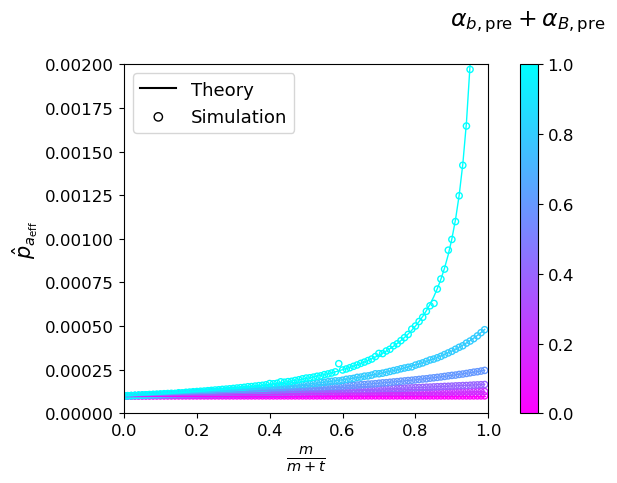

In [10]:
equi = np.loadtxt("GeneralModel_WF_Equilibria_spre" + str(0.01) +".txt")

cmap = mpl.colormaps['cool_r']
fig, ax = plt.subplots(1, 2, gridspec_kw={'width_ratios': [10, 0.5]}, figsize = (6,5) )

for sm in np.arange(0,1.01,0.2):
    sm = round(sm,4)
    inds = np.logical_and(equi[:,1] + equi[:,2] < sm + 0.01, equi[:,1] + equi[:,2] > sm - 0.01)
    ax[0].scatter(equi[inds,5],equi[inds,7]+equi[inds,9],edgecolors=cmap(sm),c='none',s=20 )
    mu = 10**(-6)
    ax[0].plot(np.arange(0,1,0.01), [mu/((1-mnorm*sm)*0.01) for mnorm in np.arange(0,1,0.01)], color = cmap(sm), linewidth =1)

ax[0].set_ylim([0,0.002])
ax[0].set_xlim([0,1])
ax[0].set_xlabel(r'$\frac{m}{m+t}$', fontsize = 15)
ax[0].set_ylabel(r'$\hat{p}_{a_{\text{eff}}}$', fontsize = 15)
ax[0].plot([-1],[-1],label = 'Theory',color='black')
ax[0].scatter([-1],[-1],label = 'Simulation',c = 'none', edgecolors='black')
ax[0].legend(fontsize=13)

cb = mpl.colorbar.ColorbarBase(ax[1], cmap=cmap, orientation='vertical')
ax[1].set_title(r'$\alpha_{b,\text{pre}} + \alpha_{B,\text{pre}}$' +' \n')
plt.tight_layout()
plt.savefig("PrechangeEqui.png",format='png')
plt.show()

## Pure Epigenetics - Haploid

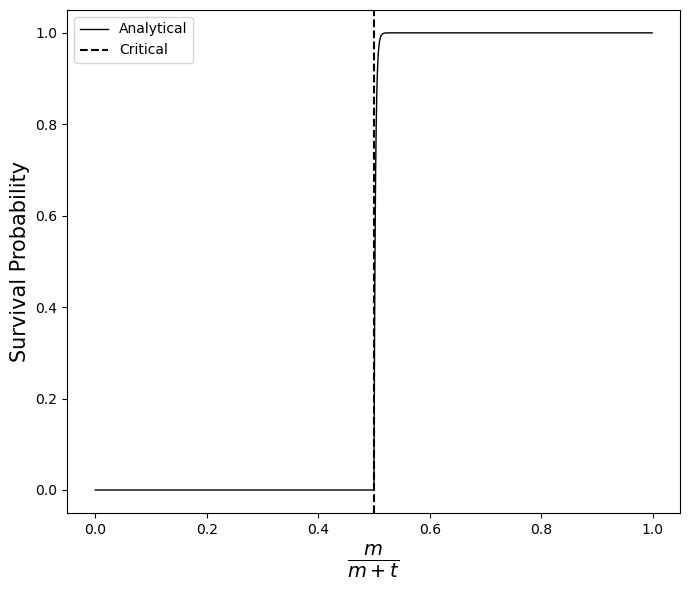

In [9]:
path = "/home/puneeth/UofT/Projects/Epigenetic Project/Code/Haploid_Epigenetics/PureEpigenetic_Data/"
m_range = np.arange(0.05,1.05,0.05)
t_range = np.arange(0.05,1.05,0.05)

r = 0.01
spre = 0.01
spost = 0.02
hbpre=0
hBpre=1
hbpost=0
hBpost=1
mu = 0
nu = 0 

mapre = 0.1
mApre = 0.1

%matplotlib inline        

N=10000

x_theoretical = np.arange(0,1,0.001)
y_theoretical = [] 
for x in x_theoretical:
    mApost = x 
    mapost = 0 
    mApre = x
    mapre = 0
    y_theoretical += [Pres(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)]
        
plt.figure(figsize = (7,6))
plt.plot(x_theoretical, y_theoretical, color='black', linewidth = 1, label = 'Analytical')
plt.axvline(x=r/(spost),linestyle = '--', color = 'black', label ='Critical')

plt.xlabel(r'$\frac{m}{m+t}$', fontsize = 20)
plt.ylabel("Survival Probability", fontsize = 15)
plt.legend()
plt.tight_layout() 
plt.savefig("PureEpi_SurProb.png",format = "png")
plt.show()

1783


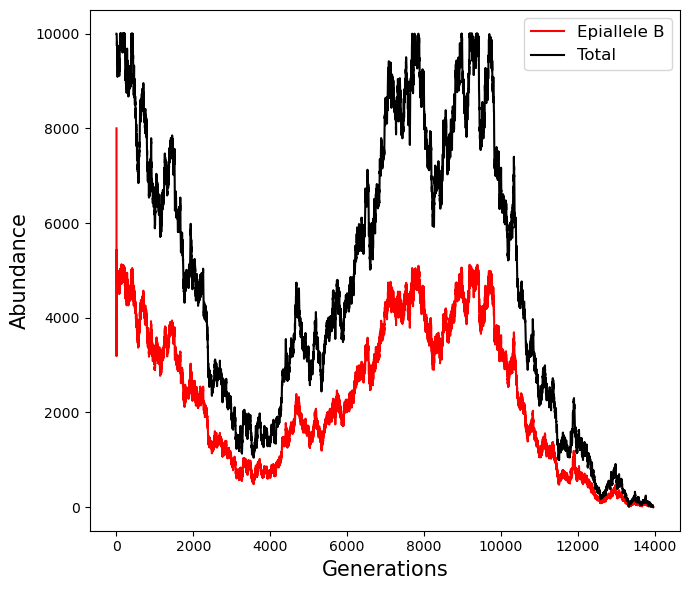

In [10]:
r = 0.01
t = 0.8
m = 0.8
mApre = m 
mApost = m 
tApre = t 
tApost = t 
hBpre = 1 
hBpost = 1
hbpre = 0 
hbpost = 0

mu = 0 
nu = 0 

mapre = 0 
mapost = 0
tapre = 0.1 #Doesn't matter what values this takes. Just needs to be non-zero so that the code doesn't breakdown 
tapost = 0.1 #Doesn't matter what values this takes. Just needs to be non-zero so that the code doesn't breakdown

spre = 0.01
spost = 0.02

N = 10000

sd = int(np.random.random()*10000)
print(sd)
np.random.seed(8825)

NA_list, NB_list, Na_list, Nb_list, recovered, extinct, num_recoveries = Post_change_stochastic_dynamics(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,tapre,tApre,tApost,tapost,mu,nu,N)
%matplotlib inline

plt.figure(figsize = (7,6))
plt.plot(range(len(NB_list)), NB_list, color = 'red', label = "Epiallele B" )
plt.plot(range(len(NB_list)), np.array(NB_list)+np.array(NA_list), color = 'black', label = "Total" )
plt.legend(fontsize = 12, loc = "upper right")
plt.ylabel("Abundance", fontsize = 15)
plt.xlabel("Generations", fontsize = 15)
plt.tight_layout()
plt.savefig("PureEpi_PopDyn.png",format="png")

## Environment specificity only - Haploid

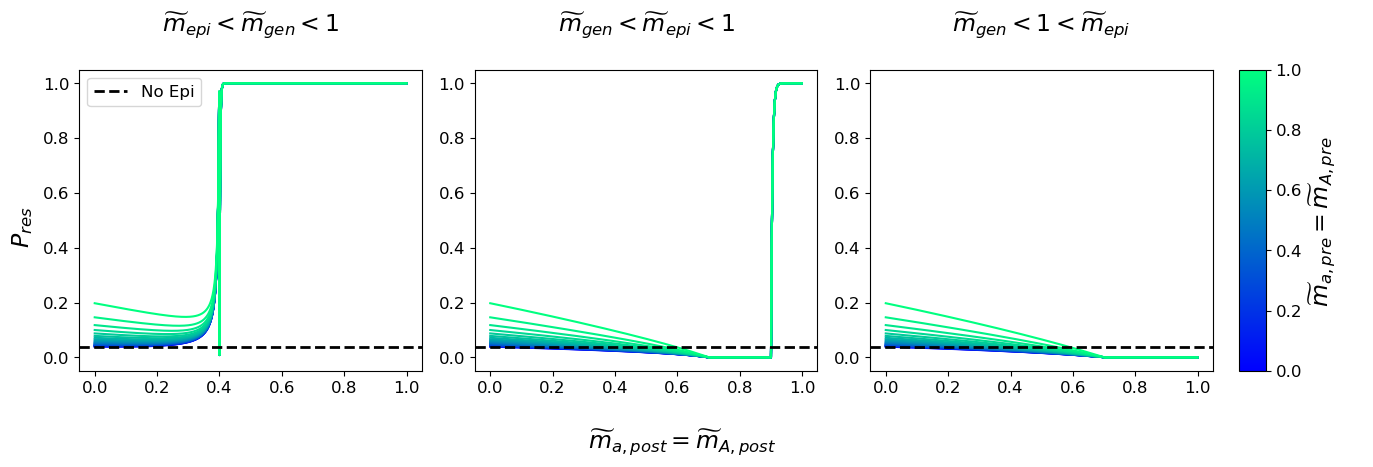

In [11]:
r=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.1
#hbpost=0.625
#hBpost=0.3
mu=10**(-6)
nu=10**(-6)
N=10**4


mpre_range = np.arange(0,1.05,0.05)
mpost_range = np.arange(0,1,0.001)

%matplotlib inline

cmap = mpl.colormaps['winter']

#hue_neg, hue_pos = 250, 15
#cmap = sns.diverging_palette(hue_neg, hue_pos, center="dark", as_cmap=True)

fig, ax = plt.subplots(1, 7, gridspec_kw={'wspace':0.0, 'width_ratios': [13,2,13,2,13,1,1]}, figsize=(14,4.7))

hpost_vals = [[(1-r/spost)/0.7,(r/spost)/0.4],[(1-r/spost)/0.7,(r/spost)/0.9],[(1-r/spost)/0.7,(r/spost)/1.1]]

for ind, [hbpost, hBpost] in enumerate(hpost_vals): 
    #hbpre = hbpost
    #hBpre = hBpost 
    
    axcur = ax[2*ind]
    ax[2*ind+1].set_visible(False)
    axcur.set_ylim([-0.05, 1.05])
    for mpre in mpre_range:
        mpre = round(mpre,5)
        mapre = mpre
        mApre = mpre
        Pres_vals = []
        for mpost in mpost_range: 
            mpost = round(mpost,5)
            mApost = mpost
            mapost = mpost
            Presval = Pres(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)
            Pres_vals += [ Presval ]
        axcur.plot(mpost_range, Pres_vals, color = cmap(mpre))
    axcur.axhline(y=1-np.exp(-2*(spost-r)*( mu/spre*N + mu/r*N*(1-mu/spre) ) ), linestyle = "--", label = "No Epi", color = 'black', linewidth =2 )
    Tgenetic = (1-r/spost)/hbpost
    Tepi = (r/spost)/hBpost
    """
    if 0<Tgenetic < 1 : 
        axcur.axvline(x=(1-r/spost)/hbpost, linestyle = '-.', color = 'grey', label = r'$\widetilde{m}_{gen}$')
    if 0<Tepi < 1:
        axcur.axvline(x=(r/spost)/hBpost, linestyle = ':', color = 'grey', label = r'$\widetilde{m}_{epi}$')
    """
    
ax[0].set_title(r'$\widetilde{m}_{epi} < \widetilde{m}_{gen} < 1$' + '\n', fontsize = 17)
ax[2].set_title(r'$\widetilde{m}_{gen} < \widetilde{m}_{epi} < 1$' + '\n', fontsize = 17)
ax[4].set_title(r'$\widetilde{m}_{gen} < 1 < \widetilde{m}_{epi}$' + '\n', fontsize = 17)


fig.supxlabel(r'$\widetilde{m}_{a,post} = \widetilde{m}_{A,post}$', fontsize = 17)
fig.supylabel(r'$P_{res}$', fontsize = 17)
ax[0].legend()

cb = mpl.colorbar.ColorbarBase(ax[-1], cmap=cmap, orientation='vertical')
ax[-1].set_ylabel(r'$\widetilde{m}_{a,pre}=\widetilde{m}_{A,pre}$' +' \n', fontsize = 17)
plt.tight_layout()
plt.savefig("AlleleIndependent.svg",format="svg")
plt.savefig("AlleleIndependent.png",format="png")
plt.show()



# Atwood only

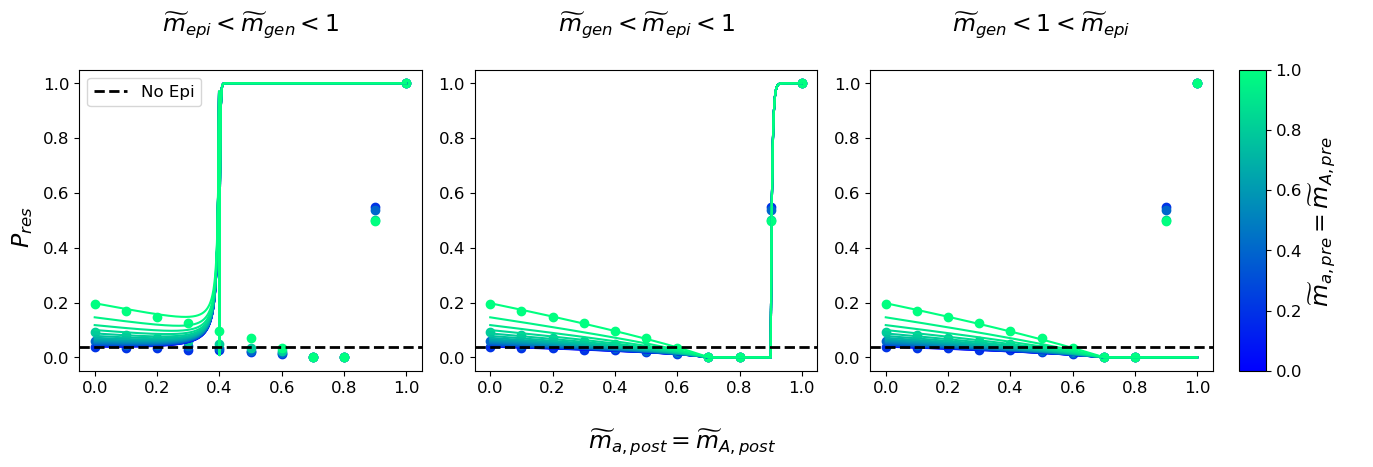

In [13]:
r=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.1
#hbpost=0.625
#hBpost=0.3
mu=10**(-6)
nu=10**(-6)
N=10**4


mpre_range = np.arange(0,1.05,0.05)
mpost_range = np.arange(0,1,0.001)

%matplotlib inline

cmap = mpl.colormaps['winter']

#hue_neg, hue_pos = 250, 15
#cmap = sns.diverging_palette(hue_neg, hue_pos, center="dark", as_cmap=True)

fig, ax = plt.subplots(1, 7, gridspec_kw={'wspace':0.0, 'width_ratios': [13,2,13,2,13,1,1]}, figsize=(14,4.7))

hpost_vals = [[(1-r/spost)/0.7,(r/spost)/0.4],[(1-r/spost)/0.7,(r/spost)/0.9],[(1-r/spost)/0.7,(r/spost)/1.1]]

for ind, [hbpost, hBpost] in enumerate(hpost_vals): 
    #hbpre = hbpost
    #hBpre = hBpost 
    
    axcur = ax[2*ind]
    ax[2*ind+1].set_visible(False)
    axcur.set_ylim([-0.05, 1.05])
    for mpre in mpre_range:
        if mpre in [0.2,0.4,0.6,0.8,1.0]:
            HaploidERwriter = pd.ExcelFile('./DataFiles/Haploid_ER_'+str(mpre)+'.xlsx')
            HaploidDF = pd.read_excel(HaploidERwriter, sheet_name = str(mpre) ,index_col=0)
            HaploidDF = HaploidDF.transpose()
            axcur.scatter(np.arange(0,1.1,0.1),1-np.array(HaploidDF[mpre]), color = cmap(mpre))
            
        mpre = round(mpre,5)
        mapre = mpre
        mApre = mpre
        Pres_vals = []
        for mpost in mpost_range: 
            mpost = round(mpost,5)
            mApost = mpost
            mapost = mpost
            Presval = Pres(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N)
            Pres_vals += [ Presval ]
        axcur.plot(mpost_range, Pres_vals, color = cmap(mpre))
    axcur.axhline(y=1-np.exp(-2*(spost-r)*( mu/spre*N + mu/r*N*(1-mu/spre) ) ), linestyle = "--", label = "No Epi", color = 'black', linewidth =2 )
    Tgenetic = (1-r/spost)/hbpost
    Tepi = (r/spost)/hBpost
    """
    if 0<Tgenetic < 1 : 
        axcur.axvline(x=(1-r/spost)/hbpost, linestyle = '-.', color = 'grey', label = r'$\widetilde{m}_{gen}$')
    if 0<Tepi < 1:
        axcur.axvline(x=(r/spost)/hBpost, linestyle = ':', color = 'grey', label = r'$\widetilde{m}_{epi}$')
    """
    
ax[0].set_title(r'$\widetilde{m}_{epi} < \widetilde{m}_{gen} < 1$' + '\n', fontsize = 17)
ax[2].set_title(r'$\widetilde{m}_{gen} < \widetilde{m}_{epi} < 1$' + '\n', fontsize = 17)
ax[4].set_title(r'$\widetilde{m}_{gen} < 1 < \widetilde{m}_{epi}$' + '\n', fontsize = 17)


fig.supxlabel(r'$\widetilde{m}_{a,post} = \widetilde{m}_{A,post}$', fontsize = 17)
fig.supylabel(r'$P_{res}$', fontsize = 17)
ax[0].legend()

cb = mpl.colorbar.ColorbarBase(ax[-1], cmap=cmap, orientation='vertical')
ax[-1].set_ylabel(r'$\widetilde{m}_{a,pre}=\widetilde{m}_{A,pre}$' +' \n', fontsize = 17)
plt.tight_layout()
plt.savefig("AlleleIndependent.svg",format="svg")
plt.savefig("AlleleIndependent.png",format="png")
plt.show()

## Allele specificity only - Haploid

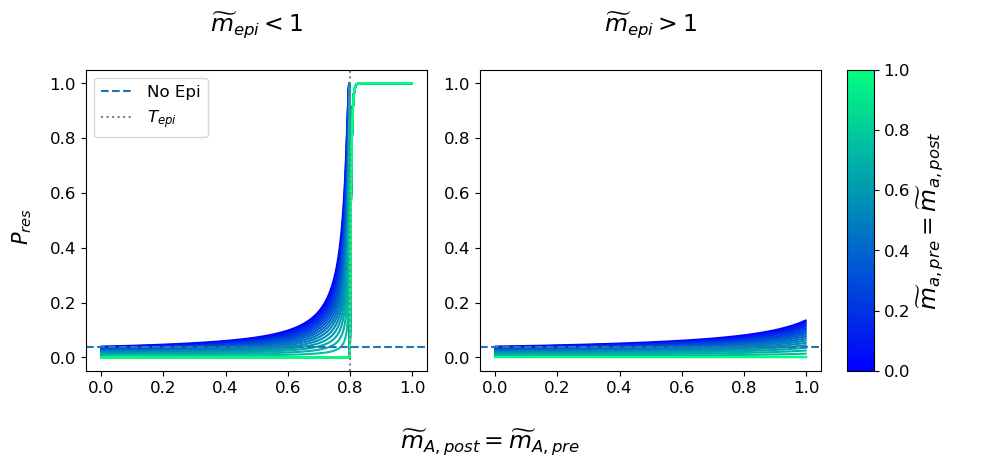

In [14]:
r=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.2
#hbpost=0.83
#hBpost=0.83
mu=10**(-6)
nu=10**(-6)
N=10**4


ma_range = np.arange(0,1.001,0.05)
mA_range = np.arange(0,1,0.001)

%matplotlib inline

cmap = mpl.colormaps['winter']

fig, ax = plt.subplots(1, 5, gridspec_kw={'wspace':0,'width_ratios': [13,2,13,1,1]}, figsize=(10,4.7))

hpost_vals = [[(1-r/spost)/0.8,(r/spost)/0.8],[(1-r/spost)/0.8,(r/spost)/1.2]]

for ind, [hbpost, hBpost] in enumerate(hpost_vals): 
    #hbpre = hbpost
    #hBpre = hBpost
    
    Tgen = (1-r/spost)/hbpost
    
    axcur = ax[ind*2]
    ax[ind*2+1].set_visible(False)
    
    axcur.set_ylim([-0.05, 1.05])
    for ma in ma_range:
        ma = round(ma,5)
        mapre = ma
        mapost = ma
        Pres_vals = []
        for mA in mA_range: 
            mA = round(mA,5)
            mApre = mA
            mApost = mA
            Pres_vals += [ Pres(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N) ]
        axcur.plot(mA_range, Pres_vals, color = cmap(ma))
        
    axcur.axhline(y=1-np.exp(-2*(spost-r)*( mu/spre*N + mu/r*N*(1-mu/spre) ) ), linestyle = "--", label = "No Epi" )
    Tepi = (r/spost)/hBpost
    if Tepi < 1:
        axcur.axvline(x=(r/spost)/hBpost, linestyle = ':', color = 'grey', label = r'$T_{epi}$')

cb = mpl.colorbar.ColorbarBase(ax[-1], cmap=cmap, orientation='vertical')
ax[-1].set_ylabel(r'$\widetilde{m}_{a,pre}=\widetilde{m}_{a,post}$' +' \n', fontsize = 17)

ax[0].set_title(r'$\widetilde{m}_{epi} < 1$' + '\n', fontsize = 17)
ax[2].set_title(r'$\widetilde{m}_{epi} > 1$' + '\n', fontsize = 17)

fig.supxlabel(r'$\widetilde{m}_{A,post} = \widetilde{m}_{A,pre}$', fontsize = 17)
fig.supylabel(r'$P_{res}$', fontsize = 15)
ax[0].legend()

ax[-2].set_ylabel(r'$\widetilde{m}_{a,post}=\widetilde{m}_{a,pre}$' +' \n', fontsize = 17)
plt.tight_layout()
plt.savefig("EnvironmentIndependent.svg",format="svg")
plt.savefig("EnvironmentIndependent.png",format="png")
plt.show()


## Environment and allele specificity - Haploid

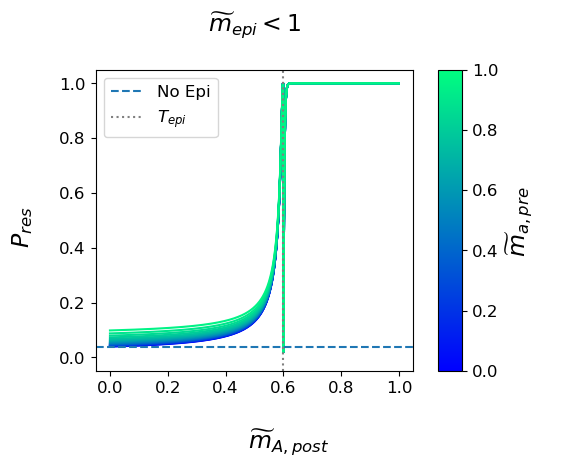

In [15]:
r=0.01
spre=0.01
spost=0.02
hbpre=0.8
hBpre=0.7
mu=10**(-6)
nu=10**(-6)
N=10**4
mapost = 0
mApre = 0

mapre_range = np.arange(0,1,0.05)
mApost_range = np.arange(0,1,0.001)

%matplotlib inline

cmap = mpl.colormaps['winter']

fig, ax = plt.subplots(1, 3, gridspec_kw={'wspace':0,'width_ratios': [13,1,1]}, figsize=(5.8,4.7))

hpost_vals = [[(1-r/spost)/0.8,(r/spost)/0.6]]

for ind, [hbpost, hBpost] in enumerate(hpost_vals): 
    Tepi = (r/spost)/hBpost
    
    axcur = ax[ind*2]
    ax[ind*2+1].set_visible(False)
    
    axcur.set_ylim([-0.05, 1.05])
    for mapre in mapre_range:
        mapre = round(mapre,5)
        #mApre = mA
        #mapost = ma
        Pres_vals = []
        for mApost in mApost_range: 
            mApost = round(mApost,5)
            #mapre = ma
            #mApost = mA
            Pres_vals += [ Pres(r,spre,spost,hbpre,hBpre,hbpost,hBpost,mapre,mApre,mapost,mApost,mu,nu,N) ]
        axcur.plot(mApost_range, Pres_vals, color = cmap(mapre))
        #axcur.arrow(ma_range[int(len(ma_range)/2)], Pres_vals[int(len(ma_range)/2)], 0.001, Pres_vals[int(len(ma_range)/2)] - Pres_vals[int(len(ma_range)/2)-1], shape='full', lw=0, length_includes_head=True, head_width=.05)

    axcur.axhline(y=1-np.exp(-2*(spost-r)*( mu/spre*N + mu/r*N*(1-mu/spre) ) ), linestyle = "--", label = "No Epi" )
    Tgenetic = (1-r/spost)/hbpost if hbpost !=0 else 2
    Tepi = (r/spost)/hBpost
    

    #if Tgenetic < 1 : 
    #    axcur.axvline(x=(1-r/spost)/hbpost, linestyle = '-.', color = 'grey', label = r'$T_{gen}$')
    if Tepi < 1:
        axcur.axvline(x=(r/spost)/hBpost, linestyle = ':', color = 'grey', label = r'$T_{epi}$')

cb = mpl.colorbar.ColorbarBase(ax[-1], cmap=cmap, orientation='vertical')
ax[-1].set_ylabel(r'$\widetilde{m}_{a,pre}$' +' \n', fontsize = 17)

ax[0].set_title(r'$\widetilde{m}_{epi} < 1$' + '\n', fontsize = 17)

fig.supxlabel(r'$\widetilde{m}_{A,post}$', fontsize = 17)
fig.supylabel(r'$P_{res}$', fontsize = 17)
ax[0].legend()

ax[-2].set_ylabel(r'$\widetilde{m}_{a,pre}$' +' \n', fontsize = 17)
plt.tight_layout()
plt.savefig("IdealCase.svg",format="svg")
plt.savefig("IdealCase.png",format="png")
plt.show()

# Diploid Model - Epimutation

In [16]:
def prechange_dipepi_det(spre,hpre_list,mapre,mApre,tapre,tApre,mu,nu,timeseries=False, NoG=10**5):
    wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre 
    
    pA = 1
    pB = 0 
    pa = 0
    pb = 0 
    
    gen = 0
    
    if timeseries: 
        pAlist = []
        pBlist = []
        palist = []
        pblist = [] 
        
    
    while True: 
        #print(pA,pa,pB,pb)
        pAs = (wAA*pA+wAa*pa+wAB*pB+wAb*pb)*pA
        pas = (wAa*pA+waa*pa+waB*pB+wab*pb)*pa
        pBs = (wAB*pA+waB*pa+wBB*pB+wBb*pb)*pB
        pbs = (wAb*pA+wab*pa+wBb*pB+wbb*pb)*pb
        
        pAmut = (1-mApre)*(1-mu)*pAs + tApre*(1-nu)*pBs + mu*pas 
        pamut = (1-mapre)*(1-mu)*pas + tapre*(1-nu)*pbs + mu*pAs 
        pBmut = (1-tApre)*(1-nu)*pBs + mApre*(1-mu)*pAs + nu*pbs
        pbmut = (1-tapre)*(1-nu)*pbs + mapre*(1-mu)*pas + nu*pBs
        
        wavg = pAmut + pamut + pBmut + pbmut    
        
        pAnext = pAmut/wavg
        pBnext = pBmut/wavg
        panext = pamut/wavg
        pbnext = 1-(pAnext+pBnext+panext)
        
        if pAnext + pBnext + panext + pbnext > 1:
            print("Negatives imminent", pAnext + pBnext + panext, pbnext)     
        
        gen += 1 
        
        if gen > NoG: 
            break
        pA = pAnext 
        pB = pBnext 
        pa = panext 
        pb = pbnext 
        
        if pA < 0 or pB < 0 or pa <0 or pb <0 : 
            raise TypeError("Negativesss", [pAlist[-1], pAs, pAmut, pA], [pBlist[-1], pBs, pBmut, pB], [palist[-1], pas, pamut, pa], [pblist[-1], pbs, pbmut, pb])
        
        if timeseries: 
            pAlist += [pA]
            pBlist += [pB]
            palist += [pa]
            pblist += [pb]
            
    if timeseries: 
        return [pAlist, palist, pBlist, pblist, pA, pa, pB, pb]
    
    return [pAnext,panext,pBnext,pbnext]

def wf_det(wAA,wAa,waa,mu,nu,timeseries=False, NoG=10**5):
    pA = 1
    pa = 0
    
    gen = 0
    , color = cmap(x)
    if timeseries: 
        pAlist = []
        palist = []
    
    while True: 
        #print(pA,pa,pB,pb)
        pAs = (wAA*pA+wAa*pa)*pA
        pas = (wAa*pA+waa*pa)*pa
        
        pAmut = (1-mu)*pAs + nu*pas 
        pamut = (1-nu)*pas + nu*pAs 
        
        wavg = pAmut + pamut
        
        pAnext = pAmut/wavg
        panext = 1-pAnext
        
        if pAnext > 1:
            print("Negatives imminent", pAnext + pBnext + panext, pbnext)     
        
        gen += 1 
        
        if gen > NoG: 
            break
        pA = pAnext 
        pa = panext 
        
        if pA < 0 or pa <0: 
            raise TypeError("Negativesss", [pAlist[-1], pAs, pAmut, pA], [pBlist[-1], pBs, pBmut, pB], [palist[-1], pas, pamut, pa], [pblist[-1], pbs, pbmut, pb])
        
        if timeseries: 
            pAlist += [pA]
            palist += [pa]
            
    if timeseries: 
        return [pAlist, palist, pA, pa]
    
    return [pA,pa]

def wf_freqdep_det(spre,hpre_list,mapre,mApre,tapre,tApre, mu, nu,timeseries=False, NoG=10**5):
    wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     
        
    pAeff = 1
    paeff = 0
    
    gen = 0
    
    if timeseries: 
        pAefflist = []
        paefflist = []
        fBlist = []
        fblist = []
    
    while True: 
        #print(pA,pa,pB,pb)
        
        
        fB0 = mApre/(mApre + tApre) 
        fA0 = 1-fB0
        fb0 = mapre/(mapre + tapre) 
        fa0 = 1-fb0
        
        wAmar = fA0*pAeff*wAA + fB0*pAeff*wAB + fa0*paeff*wAa + fb0*paeff*wAb
        wBmar = fA0*pAeff*wAB + fB0*pAeff*wBB + fa0*paeff*waB + fb0*paeff*wBb
        wamar = fA0*pAeff*wAa + fB0*pAeff*waB + fa0*paeff*waa + fb0*paeff*wab
        wbmar = fA0*pAeff*wAb + fB0*pAeff*wBb + fa0*paeff*wab + fb0*paeff*wbb
        wavg = fA0*pAeff*wAmar + fB0*pAeff*wBmar + fa0*paeff*wamar + fb0*paeff*wbmar 
        
        """
        if pAeff != 0:
            fB=1/(2*pAeff*(wAmar - wBmar))*(fa0*paeff*wamar+pAeff*wAmar+fb0*paeff*wbmar+mApre*wAmar*(1-mu)-(1-tApre)*wBmar*(1-nu)-np.sqrt((paeff*(fa0*wamar+fb0*wbmar)+wAmar*(pAeff+mApre*(1-mu))+(-1+tApre)*wBmar*(1-mu))**2+4*(wAmar-wBmar)*(mApre*pAeff*wAmar*(-1+mu)-fb0*paeff*wbmar*nu)))
        else:
            fB=0
        """
        
        fB1 = fB0*(wBmar-wavg)/(mApre+tApre) + fA0*fB0*(wAmar-wBmar)
        fB = fB0 + fB1
        fA = 1-fB
                
        fb1 = fb0*(wbmar-wavg)/(mapre+tapre) + fa0*fb0*(wamar-wbmar)
        fb = fb0 + fb1
        """
        if paeff != 0: 
            fb=1/(2*paeff*(wamar - wbmar))*(fA0*pAeff*wAmar+paeff*wamar+fB0*pAeff*wBmar+mapre*wamar*(1-mu)-(1-tapre)*wbmar*(1-nu)-np.sqrt((pAeff*(fA0*wAmar+fB0*wBmar)+wamar*(paeff+mapre*(1-mu))+(-1+tapre)*wbmar*(1-mu))**2+4*(wamar-wbmar)*(mapre*paeff*wamar*(-1+mu)-fB0*pAeff*wBmar*nu)))
        else:
            fb = 0
        """
        fa = 1-fb
        
               
        wAAeff = fA**2*wAA + 2*fA*fB*wAB + fB**2*wBB
        waaeff = fa**2*waa + 2*fa*fb*wab + fb**2*wbb
        wAaeff = fA*fa*wAa + fA*fb*wAb + fB*fa*waB + fB*fb*wBb 
        
        pAs = (wAAeff*pAeff+wAaeff*paeff)*pAeff
        pas = (wAaeff*pAeff+waaeff*paeff)*paeff
        
        pAmut = (1-mu)*pAs + nu*pas 
        pamut = (1-nu)*pas + nu*pAs 
        
        wavg = pAmut + pamut
        
        pAnext = pAmut/wavg
        panext = 1-pAnext
        
        if pAnext > 1:
            print("Negatives imminent", pAnext + pBnext + panext, pbnext)     
        
        gen += 1 
        
        if gen > NoG: 
            break
        pAeff = pAnext 
        paeff = panext 
        
        if pAeff < 0 or paeff <0: 
            raise TypeError("Negativesss", [pAlist[-1], pAs, pAmut, pA], [pBlist[-1], pBs, pBmut, pB], [palist[-1], pas, pamut, pa], [pblist[-1], pbs, pbmut, pb])
        
        if timeseries: 
            pAefflist += [pAeff]
            paefflist += [paeff]
            fBlist += [fB]
            fblist += [fb]
            
    if timeseries: 
        return [pAefflist, paefflist, fBlist, fblist, pAeff, paeff]
    
    return [pAeff,paeff]

def effectivepara_dipepi(spre,hpre_list,mapre,mApre,tapre,tApre, mu, nu): 
    wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     
    
    fA = tApre/(mApre + tApre)
    fB = 1-fA
    fa = tapre/(mapre + tapre)
    fb = 1-fa
    
    wAAeff = fA**2*wAA + 2*fA*fB*wAB + fB**2*wBB
    waaeff = fa**2*waa + 2*fa*fb*wab + fb**2*wbb
    wAaeff = fA*fa*wAa + fB*fb*wBb + fB*fa*waB + fA*fb*wAb 
    
    sAAeff = wAAeff - 1
    saaeff = waaeff - 1 
    sAaeff = wAaeff - 1 
    
    seff = (wAAeff - waaeff)/wAAeff
    sheff = (wAAeff - wAaeff)/(wAAeff)
    heff = sheff/seff
    
    if sAAeff - sAaeff > 0:
        #print("Case I: hs > 0")
        mueff = mu*tApre/(mApre+tApre) + nu*mApre/(mApre+tApre)
        pa_equi = mueff/(sAAeff-sAaeff) #- ((1 - heff)*mu**2)/(heff**3*seff**2)
    elif saaeff - sAaeff > 0:
        #print("Case II: hs < 0 and 0 < h < 1")
        mueff = mu*tapre/(mapre+tapre) + nu*mapre/(mapre+tapre)
        pa_equi = 1 - mueff/(saaeff - sAaeff) #+ ((heff)*mu**2)/((1-heff)**3*seff**2)
    elif (sAaeff-saaeff)*(sAaeff-sAAeff)/(saaeff+sAAeff-2*sAaeff): 
        #print("Case III: hs < 0 and (h < 0 or h > 1)")
        #mueff = mu*tapre/(mapre+tapre) + nu*mapre/(mapre+tapre)
        #pa_equi = 1 - mueff/((1-heff)*seff) + ((heff)*mu**2)/((1-heff)**3*seff**2)
        mueff = mu*tApre/(mApre+tApre) + nu*mApre/(mApre+tApre)
        nueff = mu*tapre/(mapre+tapre) + nu*mapre/(mapre+tapre)
        pa_equi = (sAAeff-sAaeff)/(sAAeff + saaeff - 2*sAaeff) + mueff/(sAaeff-sAAeff) + nueff/(saaeff-sAaeff) # + ( (saaeff*sAAeff-sAaeff)/(saaeff+sAAeff-2*sAaeff) +mueff/(sAaeff-sAAeff)**2 + nueff/(saaeff-sAaeff)**2 )*(mueff/(sAaeff-sAAeff)+nueff/(saaeff-sAaeff)) # sheff/(2*sheff-seff) #+ mueff/((-1 + heff)*heff*seff)-((heff*mueff)/((-1+heff)*(-1+2*heff))) + ((1+6*(-1+heff)*heff+8*(-1+heff)**2*heff**2)*mueff**2)/((-1+heff)**3*heff**3*(-1+2*heff)*seff**2)
        
        #pa_equi = 1 - pa_equi
    else:
        raise TypeError("Case IV")

    return wAAeff, waaeff, wAaeff, seff, heff, pa_equi

print("Done")

Done


In [18]:
seed = int(np.random.random()*10000) #1361, 8973- All dominance cases plus breakdown of QEE, 298
np.random.seed(8973)
print(seed)
%matplotlib inline

x_range = np.arange(0,1.05,0.05) 
hpre_list = [0,1,0.8,0.2,0.5,0.4,0.1,0.9,0.6,0.5]
hpre_list = [0,1] + [np.random.random() for i in range(8)]
spre = 0.01
mu = 10**(-6)
nu = 10**(-6)
NoG = 10**5

paeff_theory_list = []
paeff_re_theory_list = []
paeff_sim_list = []
pawf_list = []
pawf_freq_list = []

wAAeff_list = []
wAaeff_list = [] 
waaeff_list = [] 

slist = [] #List of max( (mApre+tApre)**(-1), (mapre+tapre)**(-1)) as a proxy for the goodness of the first order approx of QEE
for x in x_range: 
    x = round(x,4)
    mApre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tApre = (1-x)*mApre/x if x != 0 else np.random.random()
    mapre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tapre = (1-x)*mapre/x if x != 0 else np.random.random()
    mueff = mApre/(mApre+tApre)*nu + tApre/(mApre+tApre)*mu
    nueff = mapre/(mapre+tapre)*nu + tapre/(mapre+tapre)*mu
           
    wAAeff, waaeff, wAaeff, seff, heff, paeff_theory = effectivepara_dipepi(spre,hpre_list,mapre,mApre,tapre,tApre,mu,nu)
    pAlist, palist, pBlist, pblist, pA, pa, pB, pb = prechange_dipepi_det(spre,hpre_list,mapre,mApre,tapre,tApre,mu,nu,timeseries=True, NoG=NoG)
    pAwf, pawf = wf_det(wAAeff,wAaeff,waaeff,mueff,nueff,timeseries=False, NoG=NoG)
    pAwf_freq, pawf_freq = wf_freqdep_det(spre,hpre_list,mapre,mApre,tapre,tApre, mueff, nueff, timeseries=False, NoG=NoG)
    
    wAAeff_re, waaeff_re, wAaeff_re, seff_re, heff_re, paeff_re_theory = effectivepara_dipepi(spre,hpre_list,pb,pB,pa,pA,mu,nu)
    pAwf_re, pawf_re = wf_det(wAAeff_re,wAaeff_re,waaeff_re,mueff,nueff,timeseries=False, NoG=NoG)
    
    paeff_sim = pa + pb
    #paeff_theory = mueff/(heff*seff) if heff*seff>0 else 1 - mueff/(heff*seff)
    print(mApre,tApre,mapre,tapre, paeff_theory)
    
    pawf_list += [pawf]
    paeff_theory_list += [paeff_theory]
    paeff_re_theory_list += [paeff_re_theory]
    pawf_freq_list += [pawf_freq]
    
    paeff_sim_list += [paeff_sim]
    wAAeff_list += [wAAeff]
    wAaeff_list += [wAaeff]
    waaeff_list += [waaeff]
    
    slist += [ max( -np.log(mApre+tApre)/np.log(10),-np.log(mapre+tapre)/np.log(10),1)*40 ]

4638
0.0 0.8649531809003457 0.0 0.48480666081174395 0.00013889329840575208
0.04984825255527437 0.9471167985502129 0.04197992383133166 0.7976185527953014 0.000170121728848447
0.014328959685718186 0.12896063717146367 0.00610540093417432 0.054948608407568884 0.0002138987308002912
0.010530176543652188 0.05967100041402906 0.052036001461200666 0.2948706749468038 0.00027849967772348213
0.03307112109048402 0.13228448436193607 0.11267437819771461 0.45069751279085846 0.000380978431831934
0.16502536848290042 0.4950761054487013 0.21622451136894363 0.6486735341068309 0.0005625670833253098
0.1742214838528597 0.40651679565667265 0.27452897181686087 0.6405676009060087 0.0009533758486198135
0.23380959419739306 0.4342178177951586 0.2159779791573893 0.4011019612922945 0.002278755823914415
0.2591944675915189 0.3887917013872783 0.3302794735511912 0.4954192103267867 0.03094707731384078
0.1433663287627127 0.17522551293220445 0.7111337495066622 0.8691634716192538 0.09894657925765232
0.5998522915481727 0.59985

wAA = 1.0
waa = 0.99
wBB = 0.9937
wbb = 0.9968
wAa = 0.9928
wAB = 0.9926
wAb = 0.9999
waB = 0.9984
wab = 0.9902
wBb = 0.9904


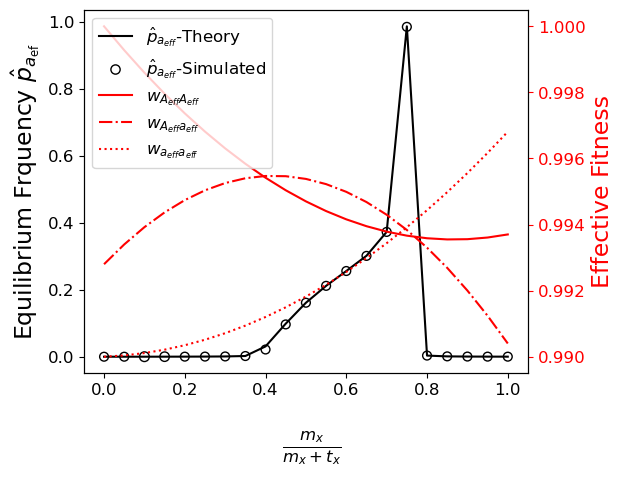

In [19]:
%matplotlib inline
fig, ax = plt.subplots(1,1)
ax_w = ax.twinx()


ax.set_ylabel(r"Equilibrium Frquency $\hat{p}_{a_{\text{ef}}}$", color = "black", fontsize = 17)
 
ax_w.plot(x_range, wAAeff_list, label = r"$w_{A_{eff}A_{eff}}$", color = 'red')
ax_w.plot(x_range, wAaeff_list, label = r"$w_{A_{eff}a_{eff}}$", color = 'red', linestyle = "-.")
ax_w.plot(x_range, waaeff_list, label = r"$w_{a_{eff}a_{eff}}$", color = 'red', linestyle = ":")
ax_w.set_ylabel("Effective Fitness", color = "red", fontsize = 17)
ax_w.tick_params(colors="red", axis = "y")

ax.plot(x_range, paeff_theory_list, color = "black",label=r"$\hat{p}_{a_{eff}}$-Theory")
ax.scatter(x_range, paeff_sim_list, c = "none",edgecolors= "black", label=r"$\hat{p}_{a_{eff}}$-Simulated", s = np.array(slist)*1 )


"""
ax_h = ax.twinx()
ax_h.plot(x_range, heff_list, label = r"$h_{eff}$", color = 'grey')
ax_h.set_ylabel("Dominance Coefficient", color = "grey", fontsize = 13)
ax_h.tick_params(colors="grey", axis = "y")
ax_h.axhline(y=0, linestyle = "--", color = "grey")
"""

fig.supxlabel(r"$\frac{m_x}{m_x+t_x}$", fontsize = 17)
fig.legend(loc="upper left",bbox_to_anchor=(0,1), bbox_transform=ax.transAxes)

plt.tight_layout()
plt.savefig("DiploidEqui.png",format="png")

genotypes = ['wAA','waa','wBB','wbb','wAa','wAB','wAb','waB','wab','wBb']
fitness = 1-np.array(hpre_list)*spre
for geno_ind, geno in enumerate(genotypes):
    print(geno + ' = ' + str(round(fitness[geno_ind],4)))

0.0035035035035035616
(45.42662708462861, 1.3284001454394456e-08)
(1.0000000000000515, 2.956156430755641e-10)


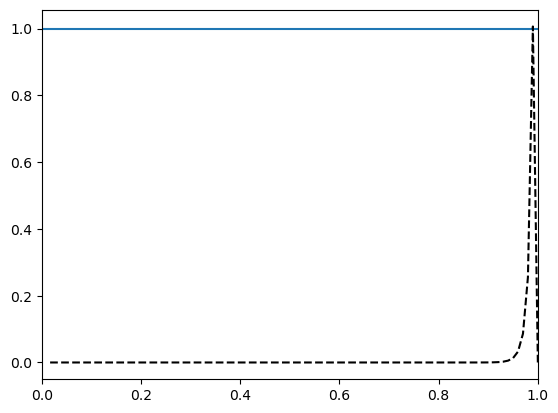

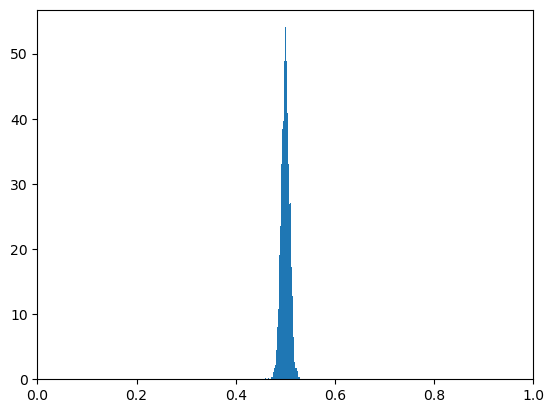

In [61]:
from math import comb
import math 

DiploidERwriter = pd.ExcelFile('./DataFiles/Prechange_Stochastic_Diploid.xlsx')
%matplotlib inline

hpre_list = [ 0,1,0.2,0.7,0.3,0.1,0.5,0.4,0.8,0.6 ] 
spre = 0.01 
N = 10**4
NoR = 10**4
mu = 10**(-6)
nu = 10**(-6)


for x in [0.5]:#np.arange(0.5,1.01,0.1):
    x = round(x,4)
    wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre
    wAAeff = (1-x)**2*wAA + 2*x*(1-x)*wAB + x**2*wBB
    waaeff = (1-x)**2*waa + 2*x*(1-x)*wab + x**2*wbb
    wAaeff = (1-x)**2*wAa + x**2*wBb + x*(1-x)*waB + x*(1-x)*wAb 
    
    sAAeff = wAAeff - 1
    saaeff = waaeff - 1 
    sAaeff = wAaeff - 1 
    
    seff = (wAAeff - waaeff)/wAAeff
    sheff = (wAAeff - wAaeff)/(wAAeff)
    
        
    
    sd = sheff 
    print(sd)
    
    DiploidDF = pd.read_excel(DiploidERwriter, sheet_name = str(x) ,index_col=0)
    
    
    import scipy.integrate as integrate
    C = integrate.quad(lambda p: np.exp(-2*N*sd*p)*(p-(p)**2)**(2*N*mu-1), 0, 1)
    print(C)
    print(integrate.quad(lambda p: np.exp(-2*N*sd*p)*(p-(p)**2)**(2*N*mu-1)/C[0], 0, 1))
    """
    theoretical_pA = []
    
    for pA in np.arange(0,1,0.01):
        val = integrate.quad(lambda p: np.exp(-(x*p*N))*(x*p*N)**(round(pA*p*N))/(math.factorial(round(pA*p*N))) , 0, 1 )
        theoretical_pA += [val]
    """
    
    theoretical = []
    for p in np.arange(0,1,0.01):
        if p != 0 :
            theoretical += [np.exp(-2*N*sd*p)*(p-(p)**2)**(2*N*mu-1)/C[0]]
        else: 
            theoretical += [0]
    plt.axhline(y=1.0)
    plt.plot(1-np.arange(0,1,0.01),np.array(theoretical), color ='black', linestyle ='dashed')
    plt.xlim(0,1)
    plt.show()
    plt.hist(np.array(DiploidDF['A']),bins=100, density=True)
    plt.xlim(0,1)
    plt.show()

In [54]:
for p in [0]:
    p =p/x 
    print(np.exp(-2*N*sd*p)*(p-p**2)**(2*N*mu-1) )

ZeroDivisionError: 0.0 cannot be raised to a negative power

In [11]:
seed = int(np.random.random()*10000) #6855 - All positives, 5170,5901 - Craziness, 7679: Case III good approx
np.random.seed(5901)

hpre_list = [0,1] + [np.random.random() for i in range(8)]
spre = 0.01
wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     

mu = 10**(-6)
nu = 10**(-6)

x = 0.65

mApre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
tApre = (1-x)*mApre/x if x != 0 else np.random.random()
mapre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
tapre = (1-x)*mapre/x if x != 0 else np.random.random()

mApre = 0.6844690815525851
tApre = 0.3685602746821612
mapre = 0.31224717993772677 
tapre = 0.16813309688954517 


mueff = mApre/(mApre+tApre)*nu + tApre/(mApre+tApre)*mu
nueff = mapre/(mapre+tapre)*nu + tapre/(mapre+tapre)*mu
    
NoG = 100000
pAlist, palist, pBlist, pblist, pA, pa, pB, pb = prechange_dipepi_det(spre,hpre_list,mapre,mApre,tapre,tApre,mu,nu,timeseries=True, NoG=NoG)
wAAeff, waaeff, wAaeff, seff, heff, paeff_theory = effectivepara_dipepi(spre,hpre_list,mapre,mApre,tapre,tApre,mu,nu)
pAwflist, pawflist, pAwf, pawf = wf_det(wAAeff,wAaeff,waaeff,mueff,nueff,timeseries=True, NoG=NoG)
pAwf_freq_list, pawf_freq_list, fB_freq_list, fb_freq_list, pA_freq_wf, pa_freq_wf = wf_freqdep_det(spre,hpre_list,mapre,mApre,tapre,tApre, mu, nu,timeseries=True, NoG=10**5)
fB_freq_list = np.array(fB_freq_list)
fA_freq_list = 1-fB_freq_list 
fb_freq_list = np.array(fb_freq_list)
fa_freq_list = 1-fb_freq_list 

wAAeff_freq_list = fA_freq_list**2*wAA + 2*fA_freq_list*fB_freq_list*wAB + fB_freq_list**2*wBB
waaeff_freq_list = fa_freq_list**2*waa + 2*fa_freq_list*fb_freq_list*wab + fb_freq_list**2*wbb
wAaeff_freq_list = fA_freq_list*fa_freq_list*wAa + fA_freq_list*fb_freq_list*wAb + fB_freq_list*fa_freq_list*waB + fB_freq_list*fb_freq_list*wBb 

%matplotlib qt

plt.figure()
plt.scatter(range(NoG),np.array(pBlist)/(np.array(pAlist) + np.array(pBlist)), color = 'black', s=1, label = r'$\frac{p_B}{p_A+p_B}$ Simulations' )
plt.plot(range(len(fB_freq_list)),fB_freq_list, color='black',linestyle='-.', label=r'$f_B^{(freq)}$ Theory - Second Order')
plt.axhline(y = mApre/(mApre+tApre), linestyle = '--', color = 'black', label= r'$\frac{m_A}{m_A+t_A}$ Theory - First Order')

plt.scatter(range(NoG),np.array(pblist)/(np.array(palist) + np.array(pblist)), color = 'grey', s=1, label= r'$\frac{p_b}{p_a+p_b}$ Simulations' )
plt.plot(range(len(fb_freq_list)),fb_freq_list, color='grey',linestyle='-.', label=r'$f_b^{(freq)}$ Theory - Second Order')
plt.axhline(y = mapre/(mapre+tapre), linestyle = '--', color = 'grey', label = r'$\frac{m_a}{m_a+t_a}$ Theory - First Order')
plt.ylabel ('QEE')
plt.ylim((mapre/(mapre+tapre)-0.01,mapre/(mapre+tapre)+0.01)) 
plt.legend()
plt.tight_layout()
plt.show() 

plt.figure() 
plt.scatter(range(NoG), np.array(palist)+np.array(pblist), color = 'none', edgecolors = 'black', s=1, label = r'$p_{a_{eff}}$ Simulations')
plt.plot(range(NoG),pawflist, linestyle = '--', color = 'black', label = r'$p_{a_{eff}}$ Theory WF')
plt.plot(range(NoG),pawflist, linestyle = '-.', color = 'black', label = r'$p_{a_{eff}}$ Theory WF Second Order')
plt.ylabel('Frequence of Alleles')
plt.tight_layout()
plt.show()

plt.figure() 
plt.scatter(range(NoG), np.array(pAlist), label = r'$p_A$ Simulations', color = 'red', s = 1)
plt.plot(range(NoG), np.array(pAwflist)*tApre/(mApre+tApre), label = r'$p_A$ Theory WF', color = 'red', linestyle='--')
plt.plot(range(NoG), np.array(pAwf_freq_list)*(1-np.array(fB_freq_list)), label = r'$p_A$ Theory WF Second Order', color = 'red', linestyle='-.')

plt.scatter(range(NoG), np.array(pBlist), label = r'$p_B$ Simulations', color = 'blue', s = 1)
plt.plot(range(NoG), np.array(pAwflist)*mApre/(mApre+tApre), label = r'$p_B$ Theory WF', color = 'blue', linestyle='--')
plt.plot(range(NoG), np.array(pAwf_freq_list)*np.array(fB_freq_list), label = r'$p_B$ Theory WF Second Order', color = 'blue', linestyle='-.')
plt.legend()
plt.ylabel('Frequency of Alleles')
plt.tight_layout()

plt.figure()
plt.scatter(range(NoG), np.array(palist), label = r'$p_a$ Simulations', color = 'green', s = 1)
plt.plot(range(NoG), np.array(pawflist)*tapre/(mapre+tapre), label = r'$p_a$ Theory WF', color = 'green', linestyle='--')
plt.plot(range(NoG), np.array(pawf_freq_list)*(1-np.array(fb_freq_list)), label = r'$p_a$ Theory WF Second Order', color = 'green', linestyle='-.')

plt.scatter(range(NoG), np.array(pblist), label = r'$p_b$ Simulations', color = 'orange', s = 1)
plt.plot(range(NoG), np.array(pawflist)*mapre/(mapre+tapre), label = r'$p_b$ Theory WF', color = 'orange', linestyle='--')
plt.plot(range(NoG), np.array(pawf_freq_list)*(np.array(fb_freq_list)), label = r'$p_b$ Theory WF Second Order', color = 'orange', linestyle='-.')
plt.ylabel('Frequency of Alleles')
plt.legend()
plt.show()

plt.figure() 
wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre 
plt.scatter(['AA','AB','BB'],[wAA,wAB,wBB])
plt.scatter(['Aa','Ab','Bb','aB'],[wAa,wAb,wBb,waB])
plt.scatter(['aa','ab','bb'],[waa,wab,wbb])
plt.xlabel("Genotypes")
plt.ylabel("Fitness")

plt.figure()
plt.plot(range(NoG), wAAeff_freq_list, label = r"$w_{A_{eff}A_{eff}}$", color = 'red')
plt.plot(range(NoG), wAaeff_freq_list, label = r"$w_{A_{eff}a_{eff}}$", color = 'pink')
plt.plot(range(NoG), waaeff_freq_list, label = r"$w_{a_{eff}a_{eff}}$", color = 'magenta')
plt.axhline(y=wAAeff, color = 'red', linestyle = "--")
plt.axhline(y=wAaeff, color = 'pink', linestyle = "--")
plt.axhline(y=waaeff, color = 'magenta', linestyle = "--")
plt.legend()
plt.ylabel('Fitness of Effective Genotypes')
plt.tight_layout()


Case II: hs < 0 and 0 < h < 1


libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast


## Diploid - Paramutation

In [33]:
def prechange_dipparamt_det(spre,hpre_list,mapre,tapre,mu,nu,timeseries=False, NoG=10**5):
    wAA,waa,wbb,wAa,wAb,wab = 1-np.array(hpre_list)*spre 
    #print(wAA,waa,wbb,wAa,wAb,wab)
    pA = 1
    pa = 0
    pb = 0 
    
    gen = 0
    
    if timeseries: 
        pAlist = []
        pBlist = []
        palist = []
        pblist = [] 
        
    
    while True: 
        
        pAs = (wAA*pA+wAa*pa+wAb*pb)*pA
        pas = (wAa*pA+waa*pa+wab*pb)*pa
        pbs = (wAb*pA+wab*pa+wbb*pb)*pb
        
        pAmut = (1-mu)*pAs + mu*pas + nu*pbs 
        pamut = (1-mu)*pas - mapre*(1-mu)*pa*(wAa*pA+wab*pb) + tapre*(1-nu)*pbs + mu*pAs 
        pbmut = (1-tapre)*(1-nu)*pbs + mapre*(1-mu)*pa*(wAa*pA+wab*pb)
        
        wavg = pAmut + pamut + pbmut    
        
        pAnext = pAmut/wavg
        panext = pamut/wavg
        pbnext = 1-round(pAnext+panext,5)
        
        if round(pAnext + panext + pbnext,5) > 1:
            print("Negatives imminent", pAnext + panext+ pbnext)     
        gen += 1 
        
        if gen > NoG: 
            break
        pA = pAnext 
        pa = panext 
        pb = pbnext 
        
        if pA < 0 or pa <0 or pb <0 : 
            raise TypeError("Negativesss", [pAs, pAmut, pA], [pas, pamut, pa], [pbs, pbmut, pb])
        
        if timeseries: 
            pAlist += [pA]
            palist += [pa]
            pblist += [pb]
            
    if timeseries: 
        return [pAlist, palist, pblist, pA, pa, pb]
    
    return [pAnext,panext,pbnext]

def analytic_dipparamt_det(spre,hpre_list,mApre,tApre,mu,nu,timeseries=False, NoG=10**5):
    wAA,waa,wbb,wAa,wAb,wab = 1-np.array(hpre_list)*spre
    tatilde = tapre/(tapre+mapre)
    matilde = mapre/(tapre+mapre)
    #wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     
    
    fb = matilde
    fa = 1 - fb
    
    waaeff = fa**2*waa + 2*fa*fb*wab + fb**2*wbb
    wAaeff = fa*wAa + fb*wAb 
    wAAeff = wAA
    
    
    mueff = mu
    nueff = mu*tatilde + nu*matilde
    
    if wAAeff > wAaeff : 
        print('1')
        pa_equi = mueff/(wAAeff - wAaeff) + mueff*(wAA-1)/(wAA-wAa) + mueff**2*(waa+wAA-2*wAa)/(wAA-wAa)**3 - mueff*nueff/(wAA-wAa)**2
    elif wAAeff == wAaeff > waaeff: 
        print('2')
        pa_equi = np.sqrt(mueff/(wAAeff - waaeff))
    elif wAAeff < wAaeff < waaeff : 
        print('3')
        pa_equi = 1 - mu/(waaeff - wAaeff)
    elif wAAeff < wAaeff == waaeff: 
        print('4')
        pa_equi = 1 - np.sqrt(mu/(waaeff - wAAeff))
    elif wAAeff < wAaeff > waaeff: 
        print('5')
        pa_equi = (wAAeff - wAaeff) / (wAAeff + waaeff - 2*wAaeff) + mueff/(wAaeff-wAAeff) + mu/(waaeff-wAaeff)
    else: 
        print('6')
        pa_equi = mueff/(mueff + mu)
    
    fa = (1 - np.sqrt(1 - 4*pa_equi*tatilde*matilde))/(2*pa_equi*matilde) if matilde !=0 else 1
    fb = 1-fa
    pa = fa*pa_equi
    pb = fb*pa_equi
    pA = 1 - pa_equi
    #print(pa_equi)
    return pa, pb


def analytic_dipparamt_det(spre,hpre_list,mapre,tapre,mu,nu,timeseries=False, NoG=10**5):
    wAA,waa,wbb,wAa,wAb,wab = 1-np.array(hpre_list)*spre
    tatilde = tapre/(tapre+mapre)
    matilde = mapre/(tapre+mapre)
    #wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     
    
    if wAb == wAA and wbb == wAA and wab == wAa: 
        s = wAA - waa 
        h = (wAA - wAa)/(wAA - waa)
        pa_genetic = mu/(wAA-wAa) if wAA-wAa != 0 else np.sqrt(mu/(wAA-waa))


        if h != 0:
            if tatilde < 1:
                pa_equi = mu/(h*s*tatilde)#-(mu*(mu*(1-h)*tatilde + nu*h*matilde))/(h**3*s**2*tatilde**2)
            elif tatilde != 0 :
                #print('1')
                A = (mu + nu)/(2*h*s*tatilde) + 1/2 
                B = mu/(h*s*tatilde)
                pa_equi = A - np.sqrt(A**2-B)
            else: 
                pa_equi = mu/(mu+nu)
        
        else: 
            if matilde < 1 - pa_genetic:
                pa_equi = (1 + mapre/tapre)*pa_genetic - (1 + mapre/tapre)**2*(mapre*nu+tapre*mu)/(2*s*(mapre+tapre))+(-mu+(mu-nu)*matilde)*(3*mu+(mu-nu)*matilde)/(8*np.sqrt(mu)*(s*tatilde**2)**1.5)
            else: 
                pa_equi = mu/(mu+nu) - mu*tatilde*((mu-nu)*(mu+nu)**2+s*mu*nu*tatilde)/(mu+nu)**4
            if pa_equi >= 1 :
                pa_equi = 1
        
        
        
    
    fa = (1 - np.sqrt(1 - 4*pa_equi*tatilde*matilde))/(2*pa_equi*matilde) if matilde !=0 else 1
    fb = 1-fa
    pa = fa*pa_equi
    pb = fb*pa_equi
    
    
    return pa, pb


In [21]:
seed = int(np.random.random()*10000) #1361, 8973- All dominance cases plus breakdown of QEE, 298
np.random.seed(seed)
print(seed)
%matplotlib inline

x_range = np.arange(0,1.01,0.05) 

hrand = 0.8
hpre_list = [0,1,0,hrand,0,hrand]
#wAA,waa,wbb,wAa,wAb,wab
#hpre_list = [0,1] + [np.random.random() for i in range(4)]
spre = 0.01
mu = 10**(-4)
nu = 10**(-4)
NoG = 10**5

pa_theory_list = []
pb_theory_list = []
pa_list = []
pb_list = []


slist = [] #List of max( (mApre+tApre)**(-1), (mapre+tapre)**(-1)) as a proxy for the goodness of the first order approx of QEE
for x in x_range: 
    x = round(x,4)
    print(x)
    mapre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tapre = (1-x)*mapre/x if x != 0 else np.random.random()
    
    pa_theory, pb_theory = analytic_dipparamt_det(spre,hpre_list,mapre,tapre,mu,nu,timeseries=False, NoG=NoG)
    pAlist, palist, pblist, pA, pa, pb = prechange_dipparamt_det(spre,hpre_list,mapre,tapre,mu,nu,timeseries=True, NoG=NoG)
    
    pa_list += [pa]
    pb_list += [pb]
    
    pa_theory_list += [pa_theory]
    pb_theory_list += [pb_theory]
    
    
    #slist += [ max( -np.log(mApre+tApre)/np.log(10),-np.log(mapre+tapre)/np.log(10),1)*40 ]

7813
0.0
0.05
0.1
0.15
0.2
0.25
0.3
0.35
0.4
0.45
0.5
0.55
0.6
0.65
0.7
0.75
0.8
0.85
0.9
0.95
1.0


/tmp/ipykernel_383121/3557908077.py:115: RuntimeWarning: divide by zero encountered in double_scalars
  pa_equi = mu/(h*s*tatilde)#-(mu*(mu*(1-h)*tatilde + nu*h*matilde))/(h**3*s**2*tatilde**2)
/tmp/ipykernel_383121/3557908077.py:135: RuntimeWarning: invalid value encountered in double_scalars
  fa = (1 - np.sqrt(1 - 4*pa_equi*tatilde*matilde))/(2*pa_equi*matilde) if matilde !=0 else 1


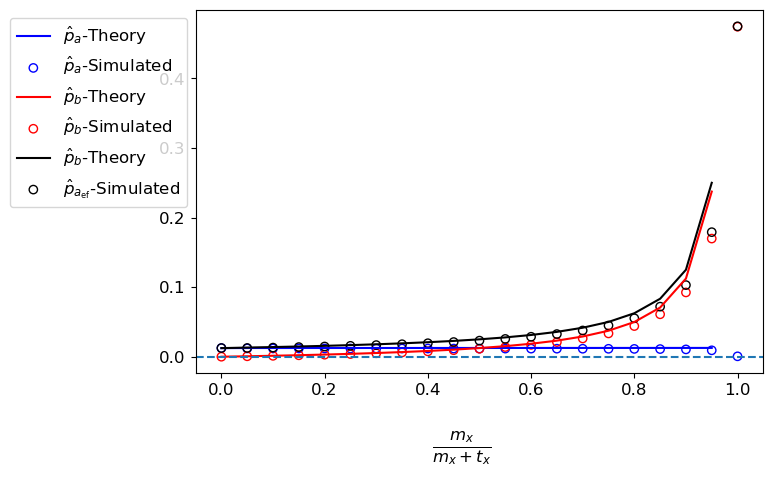

wAA = 1.0
waa = 0.99
wbb = 1.0
wAa = 0.992
wAb = 1.0
wab = 0.992


In [22]:
%matplotlib inline
fig, ax = plt.subplots(1,1)

ax.plot(x_range, pa_theory_list, color = "blue",label=r"$\hat{p}_{a}$-Theory")
ax.scatter(x_range, pa_list, c = "none",edgecolors= "blue", label=r"$\hat{p}_{a}$-Simulated" )

ax.plot(x_range, pb_theory_list, color = "red",label=r"$\hat{p}_{b}$-Theory")
ax.scatter(x_range, pb_list, c = "none",edgecolors= "red", label=r"$\hat{p}_{b}$-Simulated" )

ax.plot(x_range, np.array(pb_theory_list)+np.array(pa_theory_list), color = "black",label=r"$\hat{p}_{b}$-Theory")
ax.scatter(x_range, np.array(pb_list) + np.array(pa_list), c = "none",edgecolors= "black", label=r"$\hat{p}_{a_{\text{ef}}}$-Simulated" )

fig.supxlabel(r"$\frac{m_x}{m_x+t_x}$", fontsize = 17)
fig.legend(loc="upper right",bbox_to_anchor=(0,1), bbox_transform=ax.transAxes)
plt.tight_layout()
ax.axhline(y=0, linestyle = '--')
#plt.ylim((-0.02,0.1))
plt.show()


genotypes = ['wAA','waa','wbb','wAa','wAb','wab']
fitness = 1-np.array(hpre_list)*spre
for geno_ind, geno in enumerate(genotypes):
    print(geno + ' = ' + str(round(fitness[geno_ind],4)))

In [23]:
def prechange_dipparawt_det(spre,hpre_list,mApre,tApre,mu,nu,timeseries=False, NoG=10**5):
    wAA,waa,wBB,wAa,wAB,waB = 1-np.array(hpre_list)*spre 
    
    pA = 1
    pB = 0
    pa = 0 
    
    gen = 0
    
    if timeseries: 
        pAlist = []
        pBlist = []
        palist = []
        pblist = [] 
        
    
    while True: 
        
        pas = (waa*pa+wAa*pA+waB*pB)*pa
        pAs = (wAa*pa+wAA*pA+wAB*pB)*pA
        pBs = (waB*pa+wAB*pA+wBB*pB)*pB
        
        pamut = (1-mu)*pas + mu*pAs + nu*pBs 
        pAmut = (1-mu)*pAs - mApre*(1-mu)*pA*(wAa*pa+wAB*pB) + tApre*(1-nu)*pBs + mu*pBs 
        pBmut = (1-tApre)*(1-nu)*pBs + mApre*(1-mu)*pA*(wAa*pa+wAB*pB)
        
        wavg = pamut + pAmut + pBmut    
        
        pAnext = pAmut/wavg
        panext = pamut/wavg
        pBnext = 1-round(pAnext+panext,5)
        
        if round(panext + pAnext + pBnext,5) > 1:
            print("Negatives imminent", panext + pAnext+ pBnext)     
        gen += 1 
        
        if gen > NoG: 
            break
        pA = pAnext 
        pa = panext 
        pB = pBnext 
        
        if pA < 0 or pa <0 or pB <0 : 
            raise TypeError("Negativesss", [pAs, pAmut, pA], [pas, pamut, pa], [pBs, pBmut, pB])
        
        if timeseries: 
            pAlist += [pA]
            palist += [pa]
            pBlist += [pB]
            
    if timeseries: 
        return [pAlist, palist, pBlist, pA, pa, pB]
    
    return [pAnext,panext,pBnext]

def analytic_dipparawt_det(spre,hpre_list,mApre,tApre,mu,nu,timeseries=False, NoG=10**5):
    wAA,waa,wBB,wAa,wAB,waB = 1-np.array(hpre_list)*spre 
    tAtilde = tApre/(tApre+mApre)
    mAtilde = mApre/(tApre+mApre)
    #wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     
    
    if waB == waa and wBB == waa and wAB == wAa: 
        s = wAA - waa 
        h = (wAA - wAa)/(wAA - waa)
        pa_genetic = mu/(wAA-wAa) if wAA-wAa != 0 else np.sqrt(mu/(wAA-waa))


        if mAtilde < 0.45: 
            if h != 0 : 
                pa_equi = pa_genetic
            else : 
                pa_equi = pa_genetic*np.sqrt((tApre-mApre)/tApre) 
        elif mAtilde > 0.55 and mAtilde < 1 - pa_genetic : 
            if h!= 0 :
                print('1')
                pa_equi = (2*mu*tAtilde + nu*(1-2*tAtilde))/(2*s*tAtilde*(2*tAtilde*h+(1-2*tAtilde)*(1-h)))
            else:
                print('3')
                pa_equi = ((mAtilde-0.5)*nu+mu*tAtilde)/(s*tAtilde*(2*mAtilde-1))
        elif 0.45 <= mAtilde <= 0.55:
            pa_equi = (tApre*mu+(mApre-tApre)*nu)/(tApre*s)*(mApre/((1-h)*mApre-(1-2*h)*tApre))
        else:
            print('2')
            pa_equi = mu/(mu+nu) - (1 - h)*s*mu*nu*tApre/(mu + nu)**3
        
        
    
    fA = (1 - np.sqrt(1 - 4*(1-pa_equi)*tAtilde*mAtilde))/(2*(1-pa_equi)*mAtilde) if mAtilde !=0 else 1
    fB = 1-fA
    pA = fA*(1-pa_equi)
    pB = fB*(1-pa_equi)
    
    #print(pa_equi)
    return pa_equi, pB



In [24]:
def analytic_dipparawt_det(spre,hpre_list,mApre,tApre,mu,nu,timeseries=False, NoG=10**5):
    wAA,waa,wBB,wAa,wAB,waB = 1-np.array(hpre_list)*spre 
    tAtilde = tApre/(tApre+mApre)
    mAtilde = mApre/(tApre+mApre)
    #wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     
    
    if mAtilde <= 0.5: 
        fB = 0 
    else: 
        fB = 1 - tAtilde/mAtilde
    fA = 1 - fB 
    
    wAAeff = fA**2*wAA + 2*fA*fB*wAB + fB**2*wBB
    wAaeff = fA*wAa + fB*waB 
    waaeff = waa
    
    
    mueff = mu*tAtilde + nu*mAtilde 
    
    if wAAeff > wAaeff : 
        #print('1')
        pa_equi = mueff*wAAeff/(wAAeff - wAaeff)
    elif wAAeff == wAaeff > waaeff: 
        #print('2')
        pa_equi = np.sqrt(mueff/(wAAeff - waaeff))
    elif wAAeff < wAaeff < waaeff : 
        #print('3')
        pa_equi = 1 - mu/(waaeff - wAaeff)
    elif wAAeff < wAaeff == waaeff: 
        #print('4')
        pa_equi = 1 - np.sqrt(mu/(waaeff - wAAeff))
    elif wAAeff < wAaeff > waaeff: 
        #print('5')
        pa_equi = (wAAeff - wAaeff) / (wAAeff + waaeff - 2*wAaeff) + mueff/(wAaeff-wAAeff) + mu/(waaeff-wAaeff)
    else: 
        #print('6')
        pa_equi = mueff/(mueff + mu)
    
    fA = (1 - np.sqrt(1 - 4*(1-pa_equi)*tAtilde*mAtilde))/(2*(1-pa_equi)*mAtilde) if mAtilde !=0 else 1
    fB = 1-fA
    pA = fA*(1-pa_equi)
    pB = fB*(1-pa_equi)
    
    #print(pa_equi)
    return pa_equi, pB


In [25]:
def parawt_plot(hrand):
    seed = int(np.random.random()*10000) #1361, 8973- All dominance cases plus breakdown of QEE, 298
    np.random.seed(seed)
    print(seed)
    %matplotlib inline

    x_range = list(np.arange(0,0.41,0.05)) + list(np.arange(0.6,1,0.05)) + list(np.arange(0.96,0.99,0.01)) 
    x_range = np.arange(0,1.05,0.05)
    #hrand = 0.6
    hpre_list = [0,1,1,hrand,hrand,1]
    #wAA,waa,wBB,wAa,wAB,waB
    #hpre_list = [0,1] + [np.random.random() for i in range(4)]
    spre = 0.01
    mu = 10**(-4)
    nu = 10**(-4)
    NoG = 10**5

    pa_theory_list = []
    pB_theory_list = []
    pa_list = []
    pB_list = []


    slist = [] #List of max( (mApre+tApre)**(-1), (mapre+tapre)**(-1)) as a proxy for the goodness of the first order approx of QEE
    for x in x_range: 
        x = round(x,4)
        #print(x)
        mApre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
        tApre = (1-x)*mApre/x if x != 0 else np.random.random()

        pa_theory, pB_theory = analytic_dipparawt_det(spre,hpre_list,mApre,tApre,mu,nu,timeseries=False, NoG=NoG)
        pAlist, palist, pBlist, pA, pa, pB = prechange_dipparawt_det(spre,hpre_list,mApre,tApre,mu,nu,timeseries=True, NoG=NoG)

        pa_list += [pa]
        pB_list += [pB]

        pa_theory_list += [pa_theory]
        pB_theory_list += [pB_theory]

    %matplotlib inline
    fig, ax = plt.subplots(1,1)

    ax.plot(x_range, pa_theory_list, color = "green",label=r"$\hat{p}_{a}$-Theory")
    ax.scatter(x_range, pa_list, c = "none",edgecolors= "green", label=r"$\hat{p}_{a}$-Simulated" )

    ax.plot(x_range, pB_theory_list, color = "darkorange",label=r"$\hat{p}_{B}$-Theory")
    ax.scatter(x_range, pB_list, c = "none",edgecolors= "darkorange", label=r"$\hat{p}_{B}$-Simulated" )

    ax.plot(x_range, 1-np.array(pa_theory_list)-np.array(pB_theory_list), color = "red",label=r"$\hat{p}_{A}$-Theory")
    ax.scatter(x_range, 1-np.array(pa_list)-np.array(pB_list), c = "none",edgecolors= "red", label=r"$\hat{p}_{A}$-Simulated" )

    #ax.plot(x_range, np.array(p_theory_list)+np.array(pa_theory_list), color = "black",label=r"$\hat{p}_{b}$-Theory")
    #ax.scatter(x_range, np.array(pb_list) + np.array(pa_list), c = "none",edgecolors= "black", label=r"$\hat{p}_{a_{\text{ef}}}$-Simulated" )

    fig.supxlabel(r"$\frac{m_x}{m_x+t_x}$", fontsize = 17)
    #fig.legend(loc="upper right",bbox_to_anchor=(0,1), bbox_transform=ax.transAxes)
    plt.tight_layout()
    ax.axhline(y=pa_list[0], linestyle = '--')
    plt.ylim((-0.02,1.02))
    plt.tight_layout()
    plt.show()


    genotypes = ['wAA','waa','wbb','wAa','wAb','wab']
    fitness = 1-np.array(hpre_list)*spre
    for geno_ind, geno in enumerate(genotypes):
        print(geno + ' = ' + str(round(fitness[geno_ind],4)))

0.8
9139


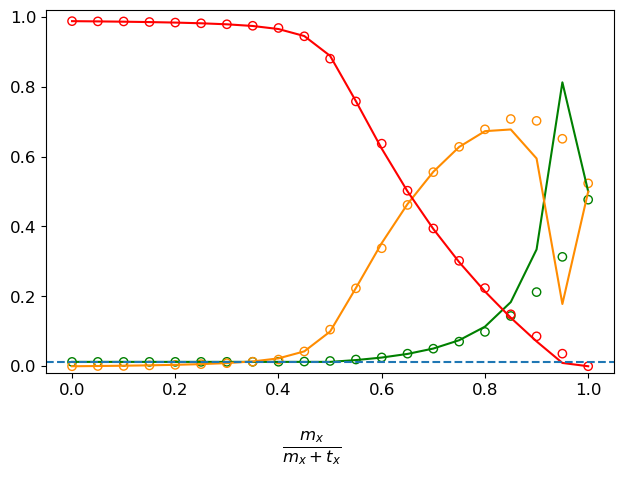

wAA = 1.0
waa = 0.99
wbb = 0.99
wAa = 0.992
wAb = 0.992
wab = 0.99


In [26]:
#for hrand in [0,0.2,0.5,0.8,1]:
for hrand in [0.8]:
    print(hrand)
    parawt_plot(hrand)

## Diploid Evolutionary Rescue

### Epimutation 

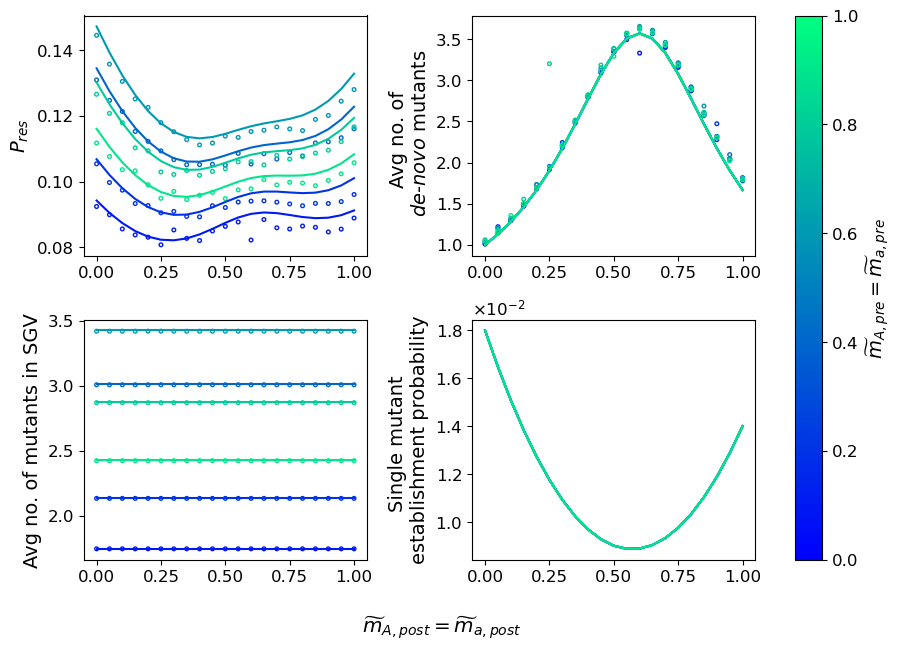

In [27]:
def Diploid_ER(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart): 
    mApre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tApre = (1-x)*mApre/x if x != 0 else np.random.random()
    mapre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tapre = (1-x)*mapre/x if x != 0 else np.random.random()
    
    mApost = np.random.random()*min(y/(1-y),1) if y != 1 else np.random.random()
    tApost = (1-y)*mApost/y if y != 0 else np.random.random()
    mapost = np.random.random()*min(y/(1-y),1) if y != 1 else np.random.random()
    tapost = (1-y)*mapost/y if y != 0 else np.random.random()
    
    output = effectivepara_dipepi(spre,hpre_list,mapre,mApre,tapre,tApre, mu, nu)
    paeff_sgv = output[-1]
    pAeff_sgv = 1-paeff_sgv
    pAsgv, pBsgv, pasgv, pbsgv = pAeff_sgv*tApre/(mApre+tApre), pAeff_sgv*mApre/(mApre+tApre), paeff_sgv*tapre/(mapre+tapre), paeff_sgv*mapre/(mapre+tapre)
    
    
    lamAA,lamaa,lamBB,lambb,lamAa,lamAB,lamAb,lamaB,lamab,lamBb = 1 - rpost + np.array(hpost_list)*spost
    
    mApost_tilde = mApost/(mApost+tApost) 
    mapost_tilde = mapost/(mapost+tapost) 
    tApost_tilde = tApost/(mApost+tApost) 
    tapost_tilde = tapost/(mapost+tapost) 
    
    lamAAeff = tApost_tilde**2*lamAA + 2*mApost_tilde*tApost_tilde*lamAB + mApost_tilde**2*lamBB 
    lamAaeff = tApost_tilde*tapost_tilde*lamAa + tApost_tilde*mapost_tilde*lamAb + mApost_tilde*tapost_tilde*lamaB + mApost_tilde*mapost_tilde*lamBb
    lamaaeff = tapost_tilde**2*lamaa + 2*mapost_tilde*tapost_tilde*lamab + mapost_tilde**2*lambb 
    
    reff = 1 - lamAAeff 
    mueff = mApost_tilde*nu + tApost_tilde*mu 
    sAaeff = lamAaeff - 1
    if sAaeff > 0: 
        Pres = 1 - np.exp(-2*sAaeff*(mueff/reff + paeff_sgv)*Nstart)
        NumMutants = mueff/reff*Nstart
        NumSGV = paeff_sgv*Nstart
    else: 
        Pres = -0.1 
        NumMutants = -0.1
        NumSGV = -0.1
    
    return Pres, NumMutants, NumSGV, sAaeff
                          

    
fig, ax = plt.subplots(2,2,figsize = (9,6.5))
#ax2 = ax.twinx()


x_range = [0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
x_range = [0.1,0.2,0.4,0.6,0.8,0.9]
cmap = mpl.colormaps['winter']

#hpre_list = [ 0,1,0.2,0.7,0.3,0.1,0.5,0.4,0.8,0.6 ] 
hpre_list = [ 0,1,0.2,0.7,0.5,0.1,0.5,0.5,0.8,0.5 ] 

#hpre_list = [0,1,0.086,0.002,0.692,0.251,0.770,0.710,0.940,0.438]
#hpre_list = [0.   , 1.   , 0.106, 0.74 , 0.821, 0.216, 0.017, 0.355, 0.498, 0.959]
hpre_list = [0,1,0.1,0.3,0.7,0.3,0.3,0.3,0.2,0.6]
#hpre_list = [0,1] + [np.random.random() for i in range(8)]
hpost_list = hpre_list

spre = 0.01 
spost = 0.04
rpost = 0.01
mu = 10**(-6)
nu = 10**(-6)
Nstart = 10**4
%matplotlib inline
for x in x_range: 
    DiploidERwriter = pd.ExcelFile('./DataFiles/Diploid_ER_'+str(x)+'.xlsx')
    
    DiploidDF = pd.read_excel(DiploidERwriter, sheet_name = str(x) ,index_col=0)
    
    Pres_theory = [Diploid_ER(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart) for y in DiploidDF.transpose().index]
    ax[0][0].scatter(DiploidDF.transpose().index,1-DiploidDF.transpose()[x],label=str(x), edgecolors= cmap(x), c='none', s = 7 )
    ax[0][0].plot(DiploidDF.transpose().index,[Pres_theory[i][0] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    
    ax[0][1].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumMutant'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[0][1].plot(DiploidDF.transpose().index,[Pres_theory[i][1] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    ax[1][0].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumSGV'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[1][0].plot(DiploidDF.transpose().index,[Pres_theory[i][2] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    ax[1][1].plot(DiploidDF.transpose().index,[Pres_theory[i][3] for i in range(len(Pres_theory)) ], color = cmap(x))
    
#plt.ylim([0,0.5])

#cb = mpl.colorbar.ColorbarBase(ax[-1][-1], cmap=cmap, orientation='vertical')
ax[0][0].set_ylabel(r'$P_{res}$')
ax[0][1].set_ylabel('\nAvg no. of \n $de$-$novo$ mutants')
ax[1][0].set_ylabel(r'Avg no. of mutants in SGV')
ax[1][1].set_ylabel('\nSingle mutant \nestablishment probability')
ax[1][1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax[1][1].yaxis.major.formatter._useMathText = True

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))

fig.supxlabel(r'$\widetilde{m}_{A,post}=\widetilde{m}_{a,post}$')

plt.tight_layout()
cbar = fig.colorbar(sm,ax=ax, fraction=0.1, pad = 0.05)
cbar.set_label(r'$\widetilde{m}_{A,pre}=\widetilde{m}_{a,pre}$')
plt.savefig('Diploid_ER.png',format='png')
plt.show()



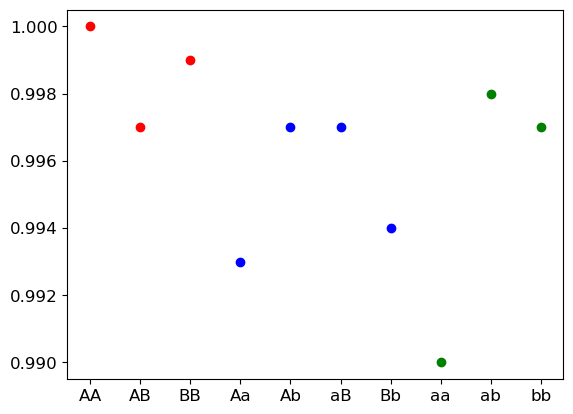

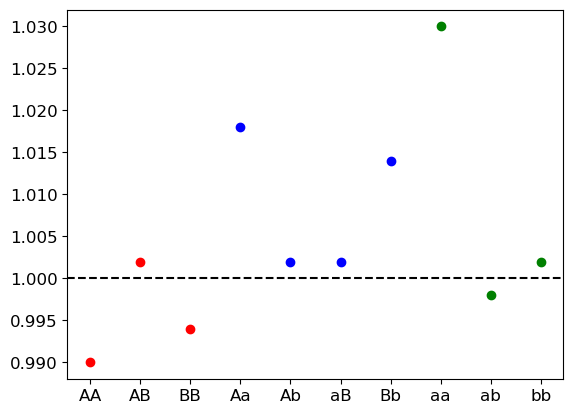

In [28]:
#hpre_list = [0,1,0.1,0.3,0.7,0.3,0.3,0.3,0.2,0.6]
wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-np.array(hpre_list)*spre     

plt.scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
plt.scatter(['Aa','Ab','aB','Bb'], [wAa,wAb,waB,wBb], color = 'blue')
plt.scatter(['aa','ab','bb'], [waa,wab,wbb], color = 'green')
plt.show()

wAA,waa,wBB,wbb,wAa,wAB,wAb,waB,wab,wBb = 1-rpost+np.array(hpre_list)*spost

plt.scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
plt.scatter(['Aa','Ab','aB','Bb'], [wAa,wAb,waB,wBb], color = 'blue')
plt.scatter(['aa','ab','bb'], [waa,wab,wbb], color = 'green')
plt.axhline(y=1.0,linestyle = '--', color ='black')
plt.show()


## Paramutation - Paramutable Wildtype

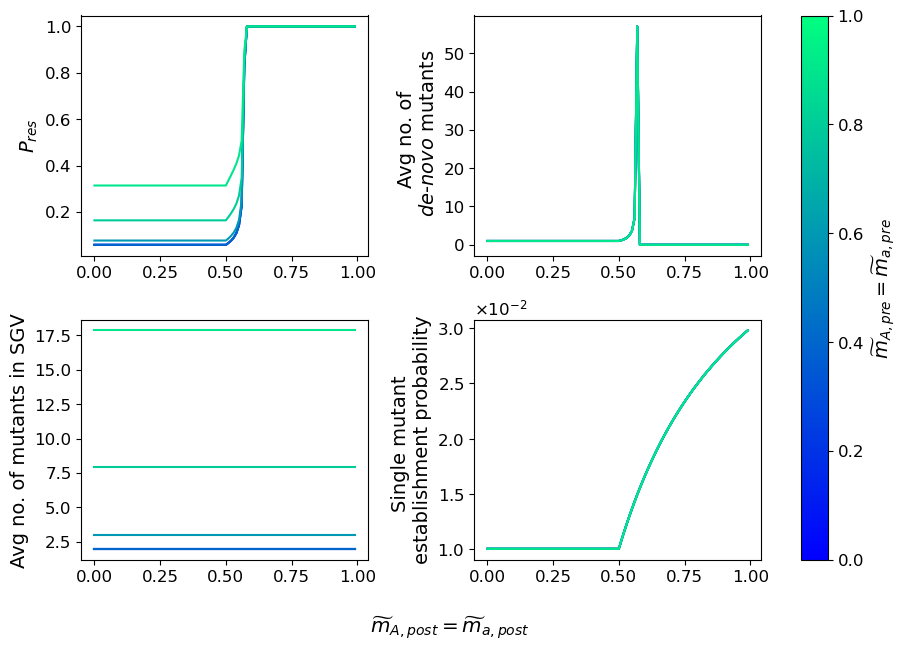

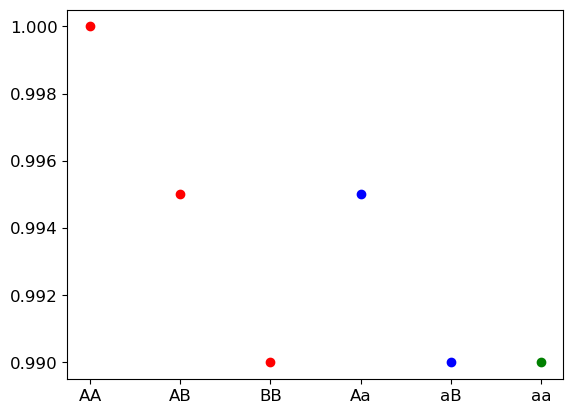

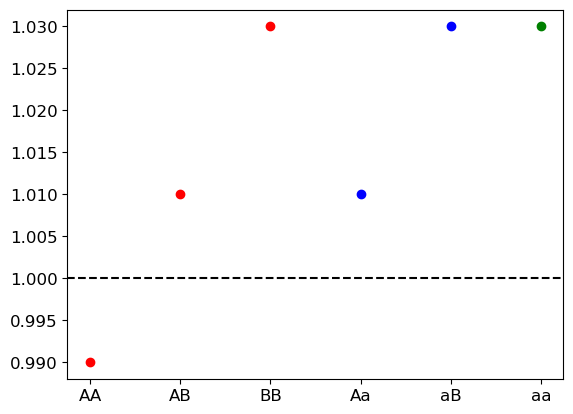

In [29]:
def Diploid_ParamutableWt_ER(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart): 
    mApre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tApre = (1-x)*mApre/x if x != 0 else np.random.random()
    
    mApost = np.random.random()*min(y/(1-y),1) if y != 1 else np.random.random()
    tApost = (1-y)*mApost/y if y != 0 else np.random.random()
    
    output = analytic_dipparawt_det(spre,hpre_list,mApre,tApre,mu,nu,timeseries=False, NoG=10**5)
    paeff_sgv = output[0]
    pAeff_sgv = 1-paeff_sgv
    pAsgv, pBsgv = pAeff_sgv*tApre/(mApre+tApre), pAeff_sgv*mApre/(mApre+tApre)
    
    lamAA,lamaa,lamBB,lamAa,lamAB,lamaB = 1 - rpost + np.array(hpost_list)*spost
    
    mApost_tilde = 1 - tApost/mApost if mApost >= tApost else 0
    tApost_tilde = 1 - mApost_tilde
    
    lamAAeff = tApost_tilde**2*lamAA + 2*mApost_tilde*tApost_tilde*lamAB + mApost_tilde**2*lamBB 
    lamAaeff = tApost_tilde*lamAa + mApost_tilde*lamaB 
    lamaaeff = lamaa
    
    reff = 1 - lamAAeff 
    mueff = mApost_tilde*nu + tApost_tilde*mu 
    sAaeff = lamAaeff - 1
    if sAaeff > 0 and reff >0: 
        Pres = 1 - np.exp(-2*sAaeff*(mueff/reff + paeff_sgv)*Nstart)
        NumMutants = mueff/reff*Nstart
        NumSGV = paeff_sgv*Nstart
    elif reff < 0: 
        Pres = 1
        NumMutants = 0
        NumSGV = paeff_sgv*Nstart
    else: 
        Pres = -0.1 
        NumMutants = -0.1
        NumSGV = -0.1
    
    return Pres, NumMutants, NumSGV, sAaeff
                          
    
fig, ax = plt.subplots(2,2,figsize = (9,6.5))
#ax2 = ax.twinx()


x_range = [0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
x_range = [0.1,0.2,0.4,0.6,0.8,0.9]
y_range = np.arange(0,1,0.01)
cmap = mpl.colormaps['winter']


h=0.5

hpre_list = [0,1] + [np.random.random() for x in range(4)]
hpre_list = [0,1,1,h,h,1]
hpost_list = hpre_list

spre = 0.01 
spost = 0.04
rpost = 0.01
mu = 10**(-6)
nu = 10**(-6)
Nstart = 10**4
%matplotlib inline
for x in x_range: 
    #DiploidERwriter = pd.ExcelFile('./DataFiles/Diploid_ER_'+str(x)+'.xlsx')
    
    #DiploidDF = pd.read_excel(DiploidERwriter, sheet_name = str(x) ,index_col=0)
    
    Pres_theory = [Diploid_ParamutableWt_ER(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart) for y in y_range]
    #ax[0][0].scatter(DiploidDF.transpose().index,1-DiploidDF.transpose()[x],label=str(x), edgecolors= cmap(x), c='none', s = 7 )
    ax[0][0].plot(y_range,[Pres_theory[i][0] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    
    #ax[0][1].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumMutant'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[0][1].plot(y_range,[Pres_theory[i][1] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    #ax[1][0].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumSGV'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[1][0].plot(y_range,[Pres_theory[i][2] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    ax[1][1].plot(y_range,[Pres_theory[i][3] for i in range(len(Pres_theory)) ], color = cmap(x))
    
#plt.ylim([0,0.5])

#cb = mpl.colorbar.ColorbarBase(ax[-1][-1], cmap=cmap, orientation='vertical')
ax[0][0].set_ylabel(r'$P_{res}$')
ax[0][1].set_ylabel('\nAvg no. of \n $de$-$novo$ mutants')
ax[1][0].set_ylabel(r'Avg no. of mutants in SGV')
ax[1][1].set_ylabel('\nSingle mutant \nestablishment probability')
ax[1][1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax[1][1].yaxis.major.formatter._useMathText = True

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))

fig.supxlabel(r'$\widetilde{m}_{A,post}=\widetilde{m}_{a,post}$')

plt.tight_layout()
cbar = fig.colorbar(sm,ax=ax, fraction=0.1, pad = 0.05)
cbar.set_label(r'$\widetilde{m}_{A,pre}=\widetilde{m}_{a,pre}$')
plt.savefig('Diploid_ER.png',format='png')
plt.show()

#hpre_list = [0,1,0.1,0.3,0.7,0.3,0.3,0.3,0.2,0.6]
wAA,waa,wBB,wAa,wAB,waB = 1-np.array(hpre_list)*spre     

plt.scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
plt.scatter(['Aa','aB'], [wAa,waB], color = 'blue')
plt.scatter(['aa'], [waa], color = 'green')
plt.show()

wAA,waa,wBB,wAa,wAB,waB = 1-rpost+np.array(hpre_list)*spost

plt.scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
plt.scatter(['Aa','aB'], [wAa,waB], color = 'blue')
plt.scatter(['aa'], [waa], color = 'green')
plt.axhline(y=1.0,linestyle = '--', color ='black')
plt.show()

## Paramutation - Paramutable Mutant 

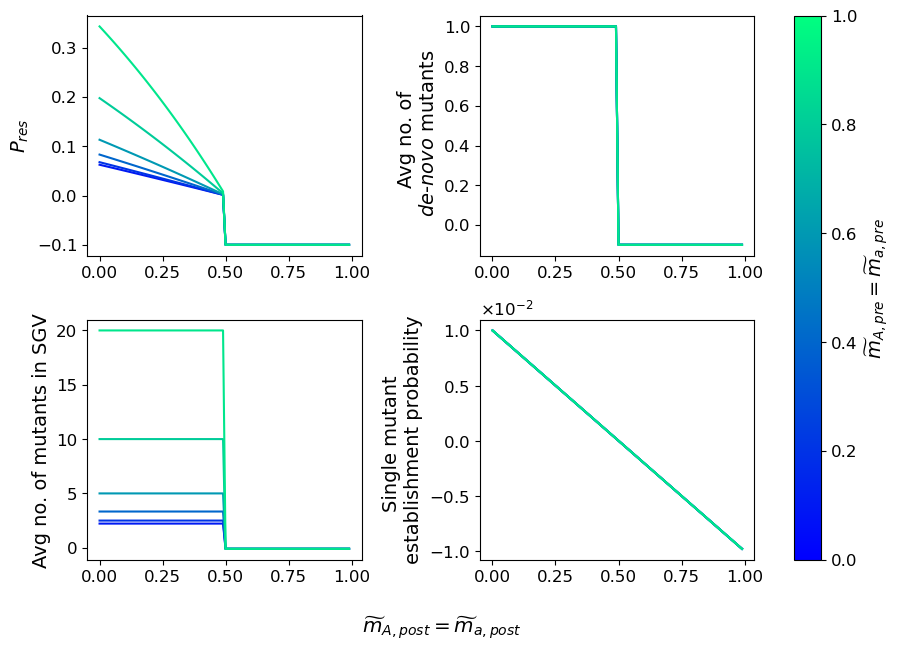

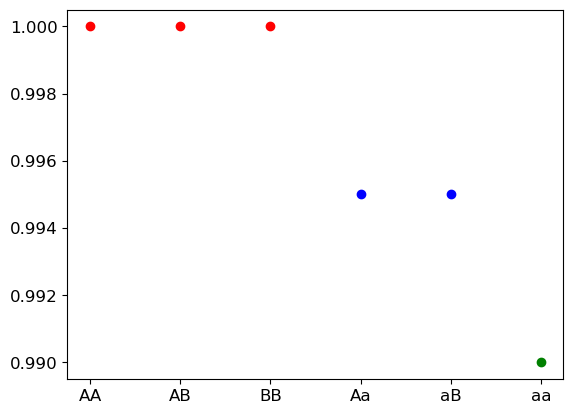

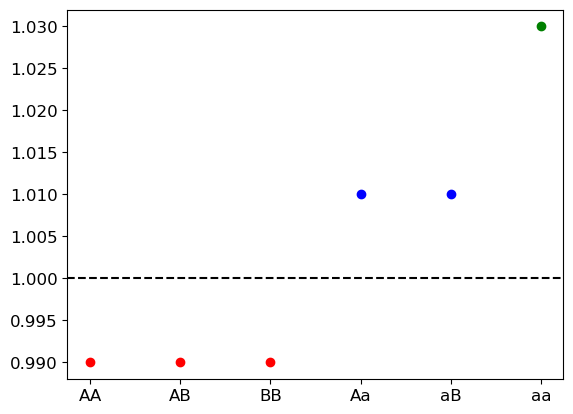

In [30]:
def Diploid_ParamutableMt_ER(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart): 
    mapre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tapre = (1-x)*mapre/x if x != 0 else np.random.random()
    
    mapost = np.random.random()*min(y/(1-y),1) if y != 1 else np.random.random()
    tapost = (1-y)*mapost/y if y != 0 else np.random.random()
    
    output = analytic_dipparamt_det(spre,hpre_list,mapre,tapre,mu,nu,timeseries=False, NoG=10**5)
    paeff_sgv = sum(output)
    pA_sgv = 1-paeff_sgv
    pasgv, pbsgv = paeff_sgv*tapre/(mapre+tapre), paeff_sgv*mapre/(mapre+tapre)
    
    lamAA,lamaa,lambb,lamAa,lamAb,lamab = 1 - rpost + np.array(hpost_list)*spost
    
    mapost_tilde = mapost/(mapost+tapost)
    #print(mapost_tilde)
    tapost_tilde = 1 - mapost_tilde
    
    lamaaeff = tapost_tilde**2*lamaa + 2*mapost_tilde*tapost_tilde*lamab + mapost_tilde**2*lambb 
    lamAaeff = tapost_tilde*lamAa + mapost_tilde*lamAb
    lamAAeff = lamAA
    
    reff = 1 - lamAAeff 
    mueff = mapost_tilde*nu + tapost_tilde*mu 
    sAaeff = lamAaeff - 1
    if sAaeff > 0 and reff > 0: 
        Pres = 1 - np.exp(-2*sAaeff*(mueff/reff + paeff_sgv)*Nstart)
        NumMutants = mueff/reff*Nstart
        NumSGV = paeff_sgv*Nstart
    elif reff < 0: 
        Pres = 1
        NumMutants = 0
        NumSGV = paeff_sgv*Nstart
    else: 
        Pres = -0.1 
        NumMutants = -0.1
        NumSGV = -0.1
    
    return Pres, NumMutants, NumSGV, sAaeff
                          
    
fig, ax = plt.subplots(2,2,figsize = (9,6.5))
#ax2 = ax.twinx()


x_range = [0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
x_range = [0.1,0.2,0.4,0.6,0.8,0.9]
y_range = np.arange(0,1,0.01)
cmap = mpl.colormaps['winter']


hrand=0.5

hpre_list = [0,1] + [np.random.random() for x in range(4)]


hpre_list = [0,1,0,hrand,0,hrand]
hpost_list = hpre_list

spre = 0.01 
spost = 0.04
rpost = 0.01
mu = 10**(-6)
nu = 10**(-6)
Nstart = 10**4
%matplotlib inline
for x in x_range: 
    #DiploidERwriter = pd.ExcelFile('./DataFiles/Diploid_ER_'+str(x)+'.xlsx')
    
    #DiploidDF = pd.read_excel(DiploidERwriter, sheet_name = str(x) ,index_col=0)
    
    Pres_theory = [Diploid_ParamutableMt_ER(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart) for y in y_range]
    #ax[0][0].scatter(DiploidDF.transpose().index,1-DiploidDF.transpose()[x],label=str(x), edgecolors= cmap(x), c='none', s = 7 )
    ax[0][0].plot(y_range,[Pres_theory[i][0] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    
    #ax[0][1].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumMutant'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[0][1].plot(y_range,[Pres_theory[i][1] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    #ax[1][0].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumSGV'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[1][0].plot(y_range,[Pres_theory[i][2] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    ax[1][1].plot(y_range,[Pres_theory[i][3] for i in range(len(Pres_theory)) ], color = cmap(x))
    
#plt.ylim([0,0.5])

#cb = mpl.colorbar.ColorbarBase(ax[-1][-1], cmap=cmap, orientation='vertical')
ax[0][0].set_ylabel(r'$P_{res}$')
ax[0][1].set_ylabel('\nAvg no. of \n $de$-$novo$ mutants')
ax[1][0].set_ylabel(r'Avg no. of mutants in SGV')
ax[1][1].set_ylabel('\nSingle mutant \nestablishment probability')
ax[1][1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax[1][1].yaxis.major.formatter._useMathText = True

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))

fig.supxlabel(r'$\widetilde{m}_{A,post}=\widetilde{m}_{a,post}$')

plt.tight_layout()
cbar = fig.colorbar(sm,ax=ax, fraction=0.1, pad = 0.05)
cbar.set_label(r'$\widetilde{m}_{A,pre}=\widetilde{m}_{a,pre}$')
plt.savefig('Diploid_ER.png',format='png')
plt.show()

#hpre_list = [0,1,0.1,0.3,0.7,0.3,0.3,0.3,0.2,0.6]
wAA,waa,wBB,wAa,wAB,waB = 1-np.array(hpre_list)*spre     

plt.scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
plt.scatter(['Aa','aB'], [wAa,waB], color = 'blue')
plt.scatter(['aa'], [waa], color = 'green')
plt.show()

wAA,waa,wBB,wAa,wAB,waB = 1-rpost+np.array(hpre_list)*spost

plt.scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
plt.scatter(['Aa','aB'], [wAa,waB], color = 'blue')
plt.scatter(['aa'], [waa], color = 'green')
plt.axhline(y=1.0,linestyle = '--', color ='black')
plt.show()

UnboundLocalError: local variable 'pa_equi' referenced before assignment

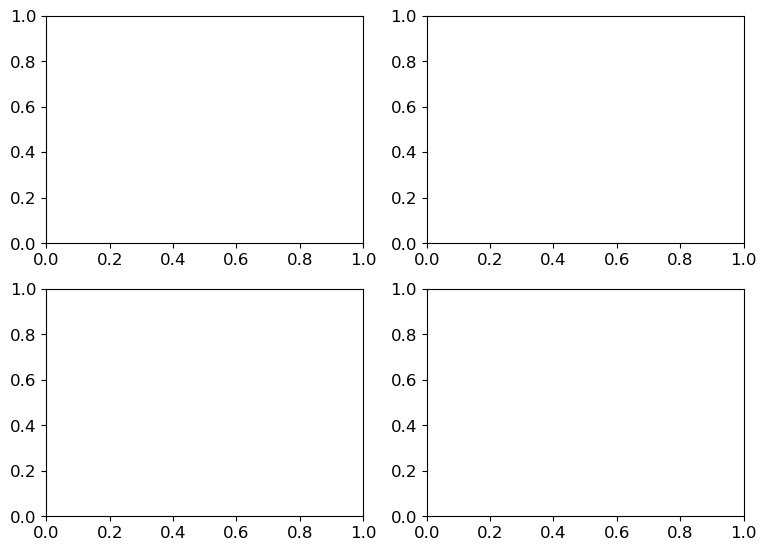

In [34]:
def Diploid_ParamutableWt_ER(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart): 
    mApre = np.random.random()*min(x/(1-x),1) if x != 1 else np.random.random()
    tBpre = (1-x)*mApre/x if x != 0 else np.random.random()
    
    mapost = np.random.random()*min(y/(1-y),1) if y != 1 else np.random.random()
    tapost = (1-y)*mApost/y if y != 0 else np.random.random()
    
    output = analytic_dipparamt_det(spre,hpre_list,mapre,tapre,mu,nu,timeseries=False, NoG=10**5)
    paeff_sgv = output[0]
    pAeff_sgv = 1-paeff_sgv
    pAsgv, pBsgv = pAeff_sgv*tApre/(mApre+tApre), pAeff_sgv*mApre/(mApre+tApre)
    
    lamAA,lamaa,lamBB,lamAa,lamAB,lamaB = 1 - rpost + np.array(hpost_list)*spost
    
    mApost_tilde = 1 - tApost/mApost if mApost >= tApost else 0
    tApost_tilde = 1 - mApost_tilde
    
    lamAAeff = tApost_tilde**2*lamAA + 2*mApost_tilde*tApost_tilde*lamAB + mApost_tilde**2*lamBB 
    lamAaeff = tApost_tilde*lamAa + mApost_tilde*lamaB 
    lamaaeff = lamaa
    
    reff = 1 - lamAAeff 
    mueff = mApost_tilde*nu + tApost_tilde*mu 
    sAaeff = lamAaeff - 1
    if sAaeff > 0 and reff >0: 
        Pres = 1 - np.exp(-2*sAaeff*(mueff/reff + paeff_sgv)*Nstart)
        NumMutants = mueff/reff*Nstart
        NumSGV = paeff_sgv*Nstart
    elif reff < 0: 
        Pres = 1
        NumMutants = 0
        NumSGV = paeff_sgv*Nstart
    else: 
        Pres = -0.1 
        NumMutants = -0.1
        NumSGV = -0.1
    
    return Pres, NumMutants, NumSGV, sAaeff
                          

    
fig, ax = plt.subplots(2,2,figsize = (9,6.5))
#ax2 = ax.twinx()


x_range = [0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
x_range = [0.1,0.2,0.4,0.6,0.8,0.9]
y_range = np.arange(0,1,0.01)
cmap = mpl.colormaps['winter']


h=0.5

hpre_list = [0,1] + [np.random.random() for x in range(4)]
hpre_list = [0,1,1,h,h,1]
hpost_list = hpre_list

spre = 0.01 
spost = 0.04
rpost = 0.01
mu = 10**(-6)
nu = 10**(-6)
Nstart = 10**4
%matplotlib inline
for x in x_range: 
    #DiploidERwriter = pd.ExcelFile('./DataFiles/Diploid_ER_'+str(x)+'.xlsx')
    
    #DiploidDF = pd.read_excel(DiploidERwriter, sheet_name = str(x) ,index_col=0)
    
    Pres_theory = [Diploid_ParamutableWt_ER(spre,spost,hpre_list,hpost_list,x,y, mu, nu, Nstart) for y in y_range]
    #ax[0][0].scatter(DiploidDF.transpose().index,1-DiploidDF.transpose()[x],label=str(x), edgecolors= cmap(x), c='none', s = 7 )
    ax[0][0].plot(y_range,[Pres_theory[i][0] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    
    #ax[0][1].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumMutant'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[0][1].plot(y_range,[Pres_theory[i][1] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    #ax[1][0].scatter(DiploidDF.transpose().index,DiploidDF.transpose()['NumSGV'],label=str(x), edgecolors= cmap(x), c='none', s = 7)
    ax[1][0].plot(y_range,[Pres_theory[i][2] for i in range(len(Pres_theory)) ], color = cmap(x))
    
    ax[1][1].plot(y_range,[Pres_theory[i][3] for i in range(len(Pres_theory)) ], color = cmap(x))
    
#plt.ylim([0,0.5])

#cb = mpl.colorbar.ColorbarBase(ax[-1][-1], cmap=cmap, orientation='vertical')
ax[0][0].set_ylabel(r'$P_{res}$')
ax[0][1].set_ylabel('\nAvg no. of \n $de$-$novo$ mutants')
ax[1][0].set_ylabel(r'Avg no. of mutants in SGV')
ax[1][1].set_ylabel('\nSingle mutant \nestablishment probability')
ax[1][1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax[1][1].yaxis.major.formatter._useMathText = True

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))

fig.supxlabel(r'$\widetilde{m}_{A,post}=\widetilde{m}_{a,post}$')

plt.tight_layout()
cbar = fig.colorbar(sm,ax=ax, fraction=0.1, pad = 0.05)
cbar.set_label(r'$\widetilde{m}_{A,pre}=\widetilde{m}_{a,pre}$')
plt.savefig('Diploid_ER.png',format='png')
plt.show()

#hpre_list = [0,1,0.1,0.3,0.7,0.3,0.3,0.3,0.2,0.6]
wAA,waa,wBB,wAa,wAB,waB = 1-np.array(hpre_list)*spre     

plt.scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
plt.scatter(['Aa','aB'], [wAa,waB], color = 'blue')
plt.scatter(['aa'], [waa], color = 'green')
plt.show()

wAA,waa,wBB,wAa,wAB,waB = 1-rpost+np.array(hpre_list)*spost

plt.scatter(['AA','AB','BB'], [wAA,wAB,wBB], color = 'red')
plt.scatter(['Aa','aB'], [wAa,waB], color = 'blue')
plt.scatter(['aa'], [waa], color = 'green')
plt.axhline(y=1.0,linestyle = '--', color ='black')
plt.show()